In [2]:
# import libraries
import math
import os
import pickle
import random
import time
import itertools
import importlib

# import numpy
import numpy as np
import matplotlib.pyplot as plt
import sklearn.preprocessing
from sklearn import preprocessing

import torch
import scipy
import scipy.io

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# import Koopman Libraries
from core.koopman_core_linear_GPU import KoopDNN_linear, KoopmanNet_linear, KoopmanNetCtrl_linear
from core.util import fit_standardizer
from models.koop_model import model_matricies, lift_raw, lift_scaled

# ===== import Frenet-real-state dynamics file =====
import dynamics.cacalv3 as cacalv3

importlib.reload(cacalv3)
from dynamics.cacalv3 import FK_solver, single_vehicle_data_gen_multi

# control
from control_files.nmpc_osqp_adapt import NonlinearMPCController
from dynamics.learned_models_control.linear_dynamics import linear_Dynamics


# ===== helper for Frenet path =====
def build_test_frenet_path_from_xy(x_ref_path, y_ref_path):
    dx_seg = np.diff(x_ref_path)
    dy_seg = np.diff(y_ref_path)
    ds_seg = np.sqrt(dx_seg ** 2 + dy_seg ** 2)
    s_ref = np.concatenate(([0.0], np.cumsum(ds_seg)))

    dx = np.gradient(x_ref_path)
    dy = np.gradient(y_ref_path)
    psi_ref = np.unwrap(np.arctan2(dy, dx))

    ds = np.gradient(s_ref)
    curvature_ref = np.gradient(psi_ref) / np.maximum(ds, 1e-8)
    curvature_ref = np.nan_to_num(curvature_ref)

    return s_ref, psi_ref, curvature_ref


# ===== Frenet -> Cartesian for plotting =====
def frenet_to_global(s_arr, ey_arr, s_ref_path, x_ref_path, y_ref_path, psi_ref_path):
    x_center = np.interp(s_arr, s_ref_path, x_ref_path)
    y_center = np.interp(s_arr, s_ref_path, y_ref_path)
    psi_center = np.interp(s_arr, s_ref_path, psi_ref_path)

    x_global = x_center - ey_arr * np.sin(psi_center)
    y_global = y_center + ey_arr * np.cos(psi_center)
    return x_global, y_global


def to_numpy(x):
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    return np.array(x)


def scale_state(x_raw, standardizer_x):
    return standardizer_x.transform(np.asarray(x_raw).reshape(1, -1)).flatten()


def scale_state_batch(X_raw, standardizer_x):
    return standardizer_x.transform(np.asarray(X_raw))


def decode_scaled_to_raw(x_scaled, standardizer_x):
    return standardizer_x.inverse_transform(np.asarray(x_scaled).reshape(1, -1)).flatten()


def clip_closed_loop_state(x, s_upper=500.0):
    x = np.asarray(x, dtype=float).copy()
    x[0] = np.clip(x[0], 0.0, s_upper)  # s
    x[1] = np.clip(x[1], -5.0, 5.0)  # e_y
    x[2] = np.clip(x[2], -1.2, 1.2)  # e_psi
    x[3] = np.clip(x[3], 0.5, 8.0)  # v_x
    x[4] = np.clip(x[4], -4.0, 4.0)  # v_y
    x[5] = np.clip(x[5], -3.0, 3.0)  # r
    return x


def is_finite_vector(x):
    x = np.asarray(x, dtype=float)
    return np.all(np.isfinite(x))


def safe_FK_step(x, u, pars, SNR_DB, i, fallback_state=None, verbose=False):
    """
    对 FK_solver 做保护：
    - 若求解结果非有限，则回退到 fallback_state 或当前状态
    - 输出统一做 clip
    """
    try:
        x_next = FK_solver(
            x, u, pars,
            sensor_noise=False,
            SNR_DB=SNR_DB,
            i=i
        )
    except Exception as e:
        if verbose:
            print(f"FK_solver exception at step {i}: {e}")
        if fallback_state is None:
            fallback_state = np.asarray(x, dtype=float).copy()
        return clip_closed_loop_state(fallback_state)

    if not is_finite_vector(x_next):
        if verbose:
            print(f"Non-finite FK_solver output at step {i}")
            print("x =", x)
            print("u =", u)
            print("x_next =", x_next)
        if fallback_state is None:
            fallback_state = np.asarray(x, dtype=float).copy()
        return clip_closed_loop_state(fallback_state)

    return clip_closed_loop_state(x_next)

Using device: cuda
GPU: NVIDIA GeForce RTX 5080


正在生成覆盖双移线边界条件的多场景数据...
X shape: (400, 500, 6)
X_changed shape: (400, 500, 6)
U shape: (400, 499, 2)
离线数据已保存。


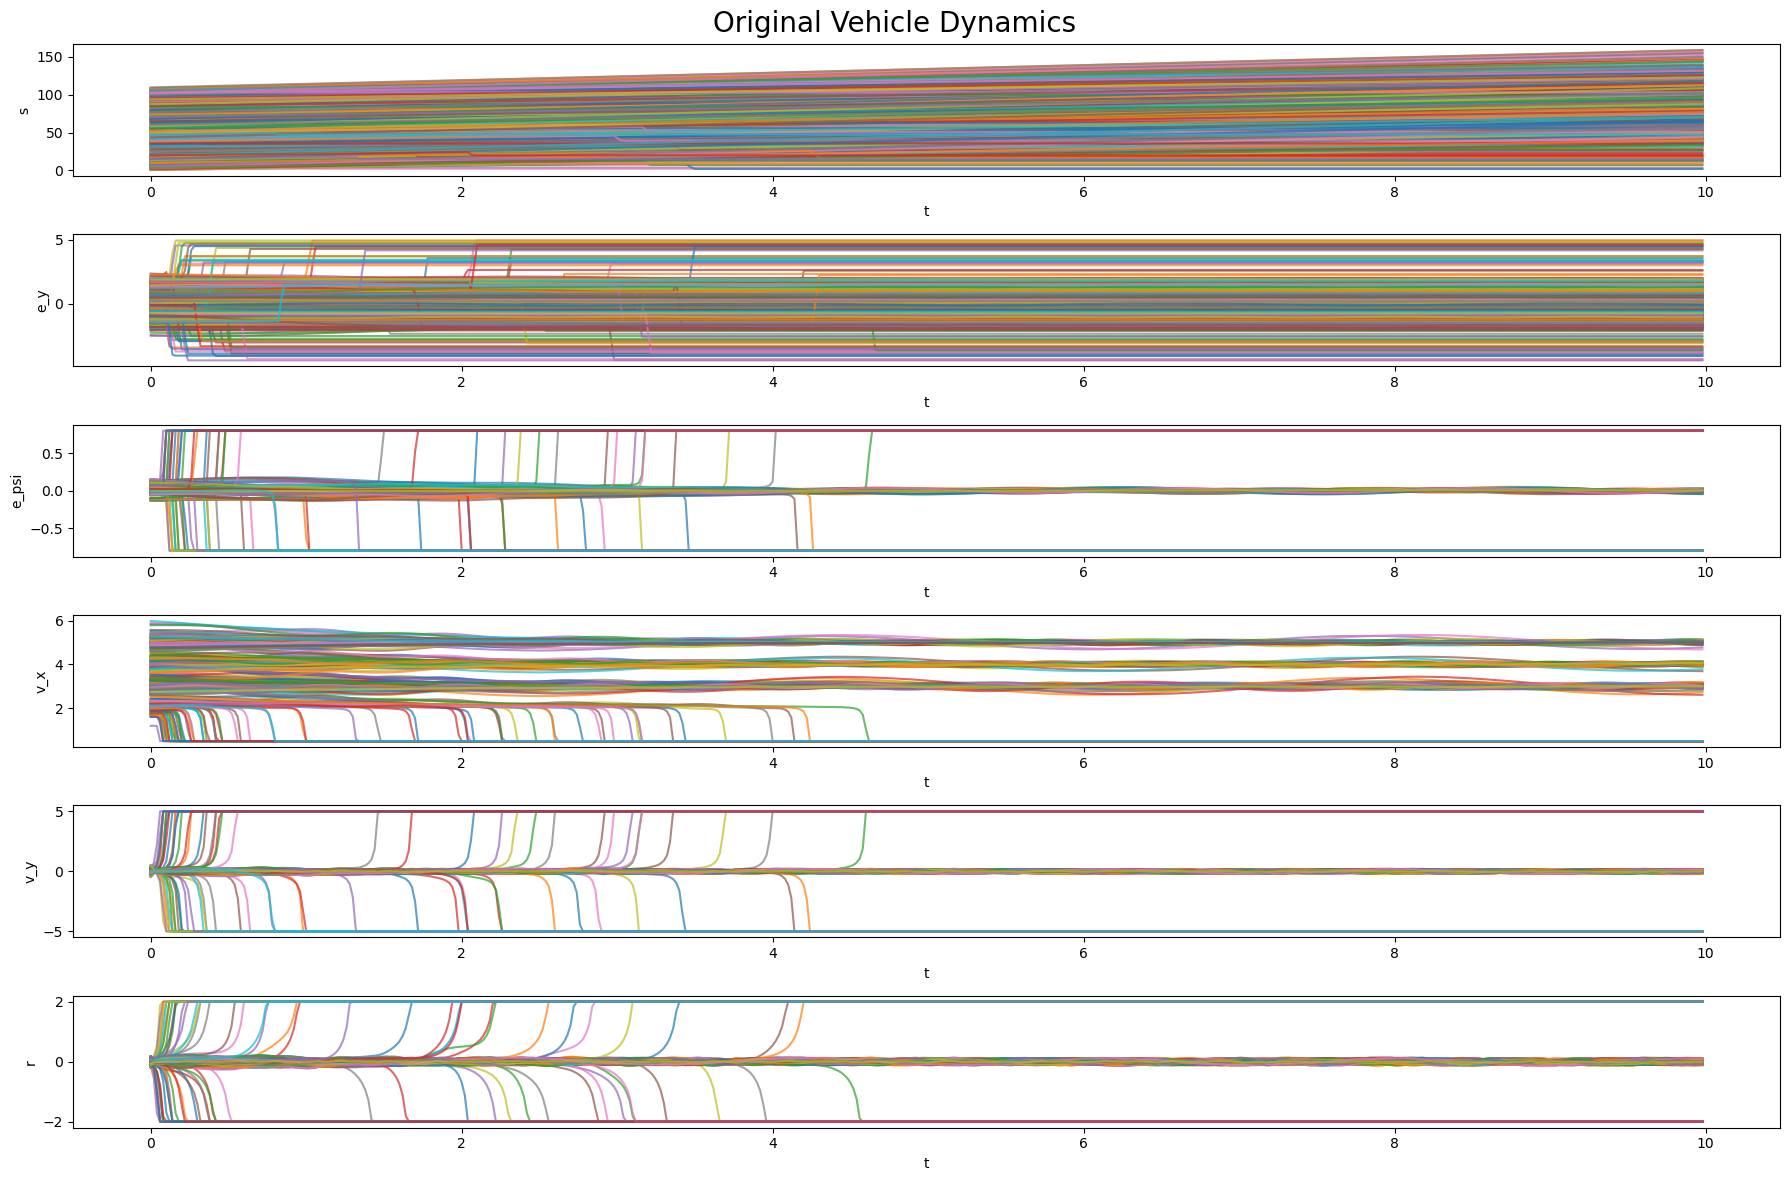

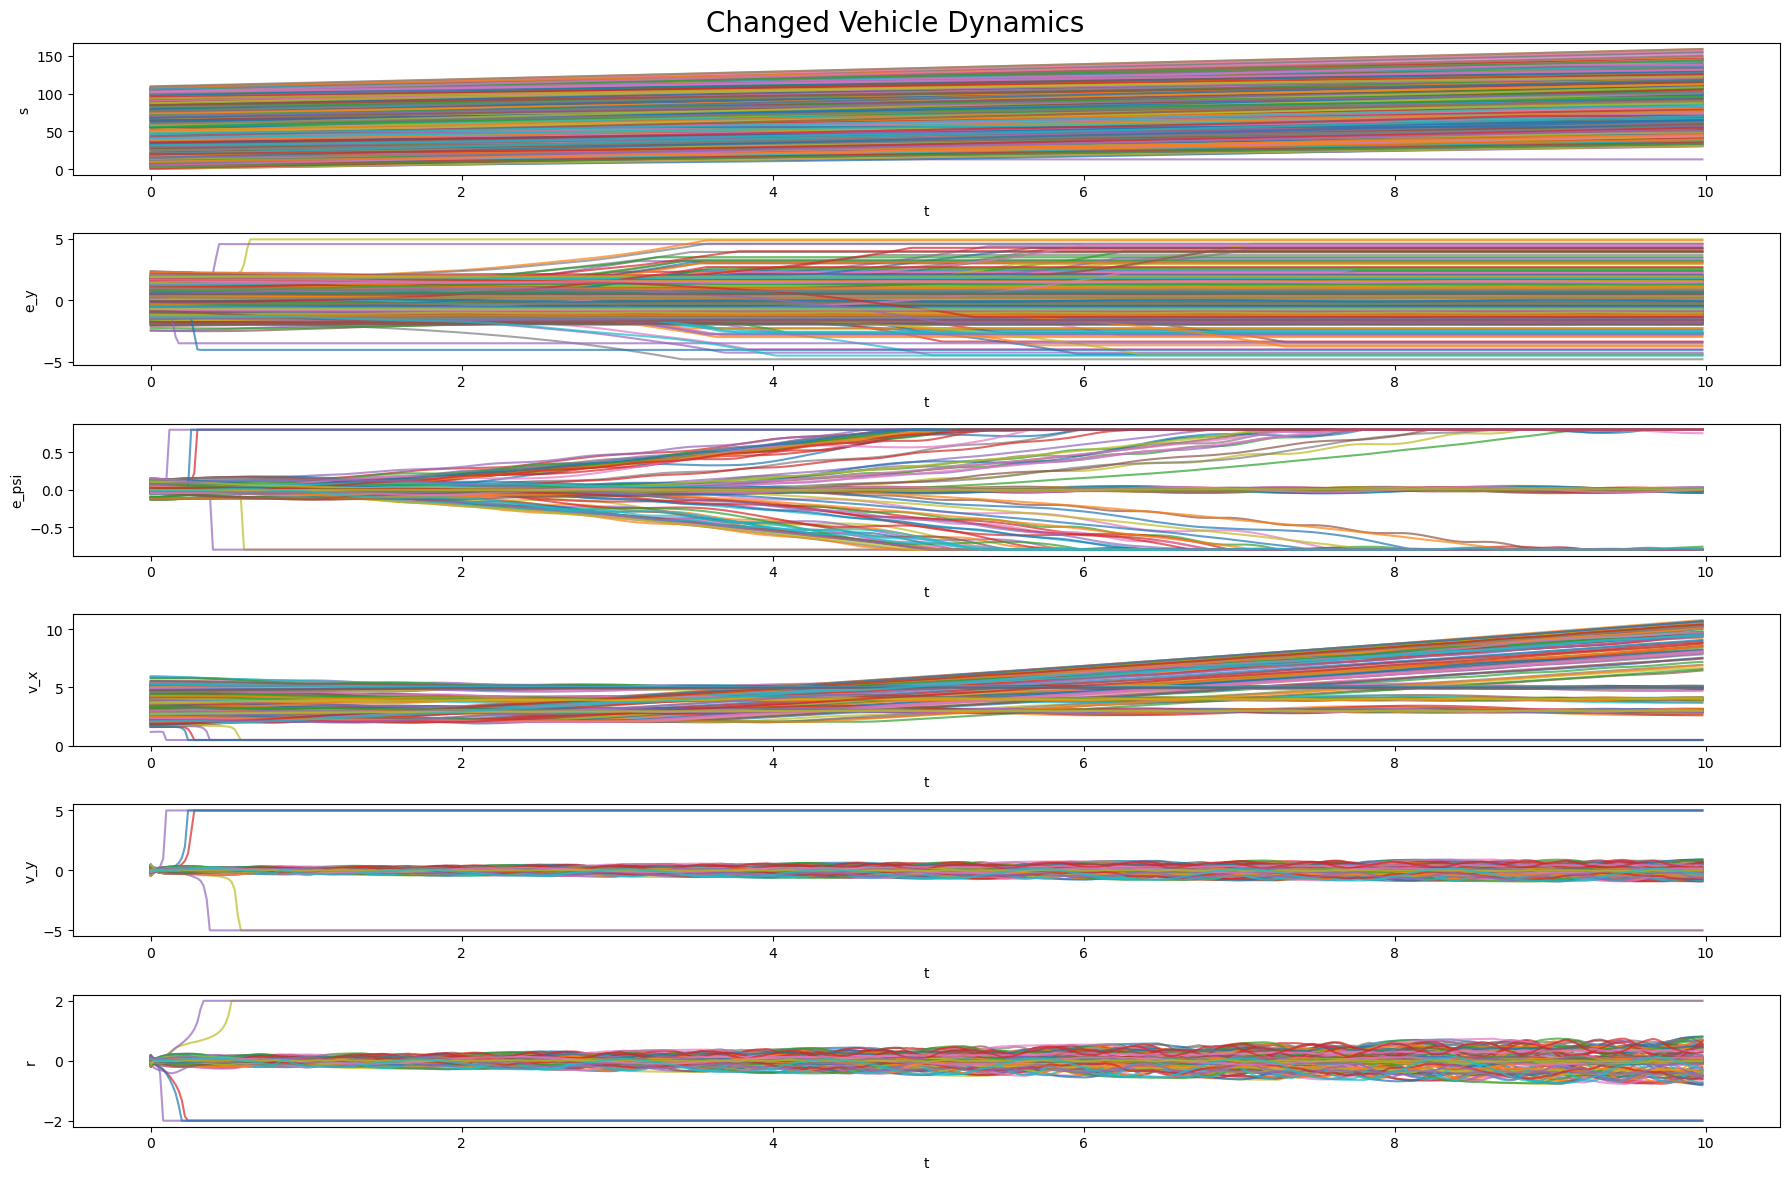

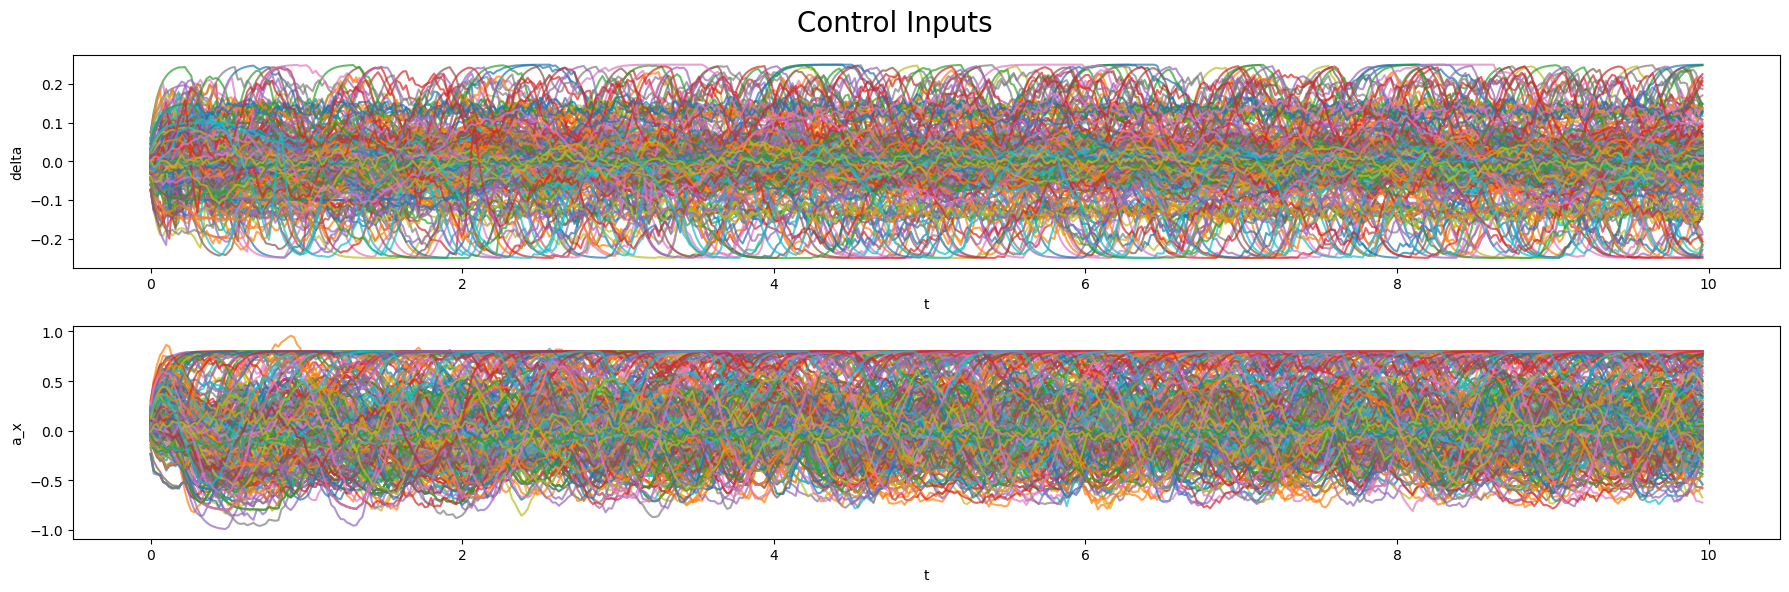

In [3]:


# =============================================================================
# 系统拟合
# =============================================================================
linear = True

# =============================================================================
# 数据生成 (针对 100m 双移线优化：丰富场景 + 物理不变性数据增强)
# =============================================================================
sys_pars_base = {}

# 6 states: x=[s, e_y, e_psi, v_x, v_y, r]
num_states = 6
num_inputs = 2
dt = 0.02

sys_pars_base["num_states"] = num_states
sys_pars_base["num_inputs"] = num_inputs
sys_pars_base["dt"] = dt

# nominal vehicle parameters
sys_pars_base["m"] = 1500.0
sys_pars_base["Iz"] = 2250.0
sys_pars_base["lf"] = 1.2
sys_pars_base["lr"] = 1.6
sys_pars_base["Cf"] = 80000.0
sys_pars_base["Cr"] = 80000.0
sys_pars_base["curvature_ref"] = 0.0
sys_pars_base["uncertainty"] = "NA"
sys_pars_base["amp"] = 0.0

sys_pars_base["road_modes"] = ['dlc']
sys_pars_base["road_mode_probs"] = [1.0]

sys_pars_base["u_modes"] = ['feedback_dominant', 'sinusoidal', 'mixed']
sys_pars_base["u_mode_probs"] = [0.40, 0.30, 0.30]  # 稍微调整激励比例

sys_pars_base["alpha_u"] = 0.70
sys_pars_base["s_margin"] = 15.0
sys_pars_base["seed"] = 42

# changed vehicle parameters
sys_pars_new_base = dict(sys_pars_base)
sys_pars_new_base["m"] = 1650.0
sys_pars_new_base["Iz"] = 2400.0
sys_pars_new_base["Cf"] = 70000.0
sys_pars_new_base["Cr"] = 70000.0

# sys_pars_new_base = dict(sys_pars_base)

sensor_noise = False
SNR_DB = 30
num_snaps = 500


configs = [
    {"vx_ref": 3.0, "delta_max": 0.10, "ax_max": 0.6, "freq": 1.0},
    {"vx_ref": 3.0, "delta_max": 0.20, "ax_max": 1.0, "freq": 0.5},  # 低频大转角，逼近紧急 DLC
    {"vx_ref": 4.0, "delta_max": 0.15, "ax_max": 0.8, "freq": 0.2},  # 中高速覆盖，拉大 e_y 侧移
    {"vx_ref": 5.0, "delta_max": 0.10, "ax_max": 0.8, "freq": 0.5},  # 高速覆盖
    {"vx_ref": 2.0, "delta_max": 0.25, "ax_max": 0.8, "freq": 0.5},  # 低速极大转角
]

num_traj_per_batch = 80
X_list, X_changed_list, U_list = [], [], []

print("正在生成覆盖双移线边界条件的多场景数据...")
for cfg in configs:
    sp = dict(sys_pars_base)
    sp.update(cfg)


    sp_new = dict(sys_pars_new_base)
    sp_new.update(cfg)


    X_b, X_changed_b, U_b = single_vehicle_data_gen_multi(
        num_traj_per_batch, num_snaps, sp, sp_new, sensor_noise, SNR_DB
    )
    X_list.append(X_b)
    X_changed_list.append(X_changed_b)
    U_list.append(U_b)

X = np.concatenate(X_list, axis=0)
X_changed = np.concatenate(X_changed_list, axis=0)
U = np.concatenate(U_list, axis=0)
num_traj = X.shape[0]  # Total 400

# 2. 【核心】数据增强 (Data Augmentation)
# 因为在直道上 (curvature_ref=0) 车辆的动态方程不受绝对纵向距离 s 和横向偏移 e_y 的影响
# 所以我们可以直接随机平移 s 和 e_y，扩大 Standardizer 的分布覆盖面，彻底解决饱和越界问题！
np.random.seed(42)
for i in range(num_traj):
    s_shift = np.random.uniform(0.0, 110.0)  # 覆盖 DLC 的 100m 长度
    ey_shift = np.random.uniform(-2.0, 2.0)  # 覆盖 DLC 的侧向偏差并留出充足泛化裕度

    X[i, :, 0] += s_shift
    X_changed[i, :, 0] += s_shift
    X[i, :, 1] += ey_shift
    X_changed[i, :, 1] += ey_shift

# 打乱数据以防止验证集切分时分布不均
indices = np.random.permutation(num_traj)
X = X[indices]
X_changed = X_changed[indices]
U = U[indices]

num_train = int(0.8 * num_traj)
num_val = num_traj - num_train



sys_pars = dict(sys_pars_base)
sys_pars.update({"vx_ref": 3.0, "delta_max": 0.05, "ax_max": 0.6, "freq": 1.0})

sys_pars_new = dict(sys_pars_new_base)
sys_pars_new.update({"vx_ref": 3.0, "delta_max": 0.05, "ax_max": 0.6, "freq": 1.0})

print("X shape:", X.shape)
print("X_changed shape:", X_changed.shape)
print("U shape:", U.shape)

os.makedirs("saved_data/single_vehicle", exist_ok=True)

np.savez_compressed(
    "saved_data/single_vehicle/offline_dataset.npz",
    X=X,
    X_changed=X_changed,
    U=U
)

with open("saved_data/single_vehicle/offline_dataset_pars.pkl", "wb") as f:
    pickle.dump({
        "sys_pars": sys_pars,
        "sys_pars_new": sys_pars_new,
        "num_traj": num_traj,
        "num_train": num_train,
        "num_val": num_val,
        "num_snaps": num_snaps,
        "sensor_noise": sensor_noise,
        "SNR_DB": SNR_DB
    }, f)

print("离线数据已保存。")

state_labels = ["s", "e_y", "e_psi", "v_x", "v_y", "r"]
input_labels = ["delta", "a_x"]
t_train = np.linspace(0, dt * (num_snaps - 1), num_snaps)

plt.figure(figsize=(18, 12))
for j in range(num_traj):
    for i in range(num_states):
        plt.subplot(num_states, 1, i + 1)
        plt.plot(t_train, X[j, :, i], alpha=0.7)
        plt.ylabel(state_labels[i])
        plt.xlabel("t")
plt.suptitle("Original Vehicle Dynamics", fontsize=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 12))
for j in range(num_traj):
    for i in range(num_states):
        plt.subplot(num_states, 1, i + 1)
        plt.plot(t_train, X_changed[j, :, i], alpha=0.7)
        plt.ylabel(state_labels[i])
        plt.xlabel("t")
plt.suptitle("Changed Vehicle Dynamics", fontsize=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 6))
for j in range(num_traj):
    for i in range(num_inputs):
        plt.subplot(num_inputs, 1, i + 1)
        plt.plot(t_train[:-1], U[j, :, i], alpha=0.7)
        plt.ylabel(input_labels[i])
        plt.xlabel("t")
plt.suptitle("Control Inputs", fontsize=20)
plt.tight_layout()
plt.show()

Model save path: saved_models/single_vehicle/linear/Koop_vehicle_Dim20_dt_0.02.pth
进一步严格对齐检查...
原始形状 → xs_train: (320, 500, 6) | us_train: (320, 499, 2)
原始形状 → xs_val:   (80, 500, 6)   | us_val:   (80, 499, 2)
强制对齐后 → xs_train: (320, 499, 6) | us_train: (320, 499, 2)
强制对齐后 → xs_val:   (80, 499, 6)   | us_val:   (80, 499, 2)
✅ U_curr 与 X_curr 样本数匹配: 159680
✅ U_curr 与 X_curr 样本数匹配: 39920
Epoch [  10/300] | Train  total=1.4956e-03  pred=5.6806e-04  lifted=1.3299e-04| Val    total=1.5724e-03  pred=7.2022e-04  lifted=1.7004e-04
Epoch [  20/300] | Train  total=6.8461e-04  pred=5.1417e-04  lifted=1.6258e-04| Val    total=8.2455e-04  pred=6.6836e-04  lifted=1.9244e-04
Epoch [  30/300] | Train  total=5.3888e-04  pred=5.1264e-04  lifted=1.2345e-04| Val    total=6.7558e-04  pred=6.5040e-04  lifted=1.5660e-04
Epoch [  40/300] | Train  total=5.2086e-04  pred=5.0279e-04  lifted=2.7181e-04| Val    total=6.5910e-04  pred=6.4067e-04  lifted=2.5693e-04
Epoch [  50/300] | Train  total=5.1817e-04  pred=4.

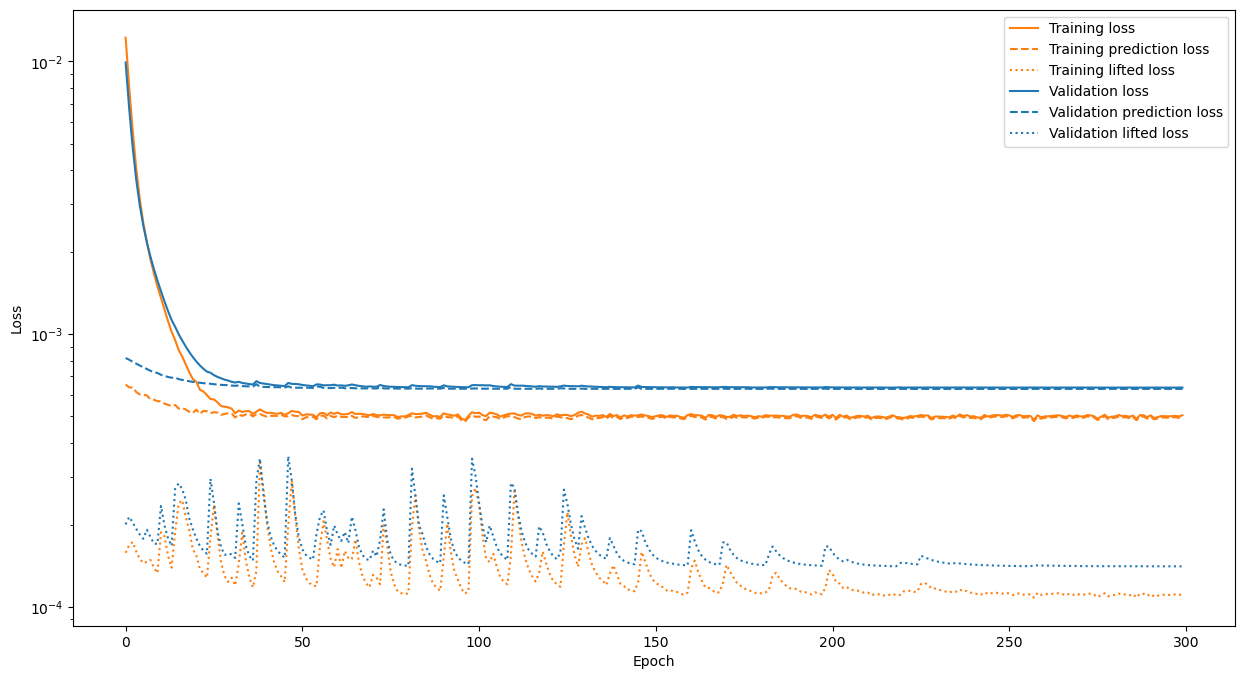

In [4]:

# =============================================================================
# Learning Koopman
# =============================================================================
xs_train, us_train = X[:num_train, :, :], U[:num_train, :, :]
xs_val, us_val = X[num_train:, :, :], U[num_train:, :, :]

net_params_lin = {}
net_params_lin["state_dim"] = num_states
net_params_lin["ctrl_dim"] = num_inputs
net_params_lin["encoder_hidden_width"] = 96
# 模型容量适度提升：场景增多变复杂了，给隐变量输出更多维度
net_params_lin["encoder_hidden_depth"] = 4
net_params_lin["encoder_output_dim"] = 20
net_params_lin["optimizer"] = "adam"
net_params_lin["activation_type"] = "tanh"
net_params_lin["lr"] = 5e-4
net_params_lin["epochs"] = 300
net_params_lin["batch_size"] = 4096

net_params_lin["eig_loss"] = True
net_params_lin["eig_loss_coeff"] = 0.2
net_params_lin["lifted_loss_penalty"] = 0.05

net_params_lin["l2_reg"] = 1e-4
net_params_lin["l1_reg"] = 1e-7
net_params_lin["first_obs_const"] = True
net_params_lin["override_C"] = True
net_params_lin["dt"] = dt
net_params_lin["weight_decay"] = 5e-5   # 轻微L2正则辅助


train = True
standardize = True

os.makedirs("saved_models/single_vehicle/linear", exist_ok=True)

file_koop_linear = (
        "saved_models/single_vehicle/linear/"
        + "Koop_vehicle_Dim"
        + str(net_params_lin["encoder_output_dim"])
        + "_dt_"
        + str(dt)
        + ".pth"
)

print("Model save path:", file_koop_linear)

standardizer_u_kdnn = fit_standardizer(
    us_train, preprocessing.StandardScaler(with_mean=True)
)
standardizer_x_kdnn = fit_standardizer(
    xs_train, preprocessing.StandardScaler(with_mean=True)
)



torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.set_float32_matmul_precision('high')
torch.cuda.empty_cache()

# RTX 50 系列额外推荐
torch.backends.cudnn.allow_tf32 = True
torch.backends.cuda.matmul.allow_tf32 = True

if train:
    if standardize:
        net = KoopmanNetCtrl_linear(
            net_params_lin,
            standardizer_x=standardizer_x_kdnn,
            standardizer_u=standardizer_u_kdnn,
            device=DEVICE
        )
    else:
        net = KoopmanNetCtrl_linear(
            net_params_lin,
            device=DEVICE
        )

    model_koop_dnn_lin = KoopDNN_linear(net)
    model_koop_dnn_lin.set_datasets(
        xs_train,
        u_train=us_train,
        x_val=xs_val,
        u_val=us_val
    )

    # print("数据形状检查：")
    # print(f"xs_train shape: {xs_train.shape} | us_train shape: {us_train.shape}")
    # print(f"xs_val shape:   {xs_val.shape}   | us_val shape:   {us_val.shape}")
    #
    # # 强制对齐每条轨迹的长度（预防根源问题）
    # min_len_train = min(xs_train.shape[1], us_train.shape[1])
    # xs_train = xs_train[:, :min_len_train, :]
    # us_train = us_train[:, :min_len_train, :]
    #
    # min_len_val = min(xs_val.shape[1], us_val.shape[1])
    # xs_val = xs_val[:, :min_len_val, :]
    # us_val = us_val[:, :min_len_val, :]
    #
    # print(f"对齐后 → xs_train: {xs_train.shape} | us_train: {us_train.shape}")
    print("进一步严格对齐检查...")

    # ====================== 强制对齐 x 和 u 的轨迹长度 ======================
    print(f"原始形状 → xs_train: {xs_train.shape} | us_train: {us_train.shape}")
    print(f"原始形状 → xs_val:   {xs_val.shape}   | us_val:   {us_val.shape}")

    # 以 u 的长度为准（因为 u 通常比 x 少一步），统一裁剪 x
    min_t_train = min(xs_train.shape[1], us_train.shape[1])
    xs_train = xs_train[:, :min_t_train, :]
    us_train = us_train[:, :min_t_train, :]

    min_t_val = min(xs_val.shape[1], us_val.shape[1])
    xs_val = xs_val[:, :min_t_val, :]
    us_val = us_val[:, :min_t_val, :]

    print(f"强制对齐后 → xs_train: {xs_train.shape} | us_train: {us_train.shape}")
    print(f"强制对齐后 → xs_val:   {xs_val.shape}   | us_val:   {us_val.shape}")

    # 再次断言，确保 process 前完全一致
    assert xs_train.shape[1] == us_train.shape[1], f"对齐失败: x={xs_train.shape[1]} vs u={us_train.shape[1]}"
    assert xs_val.shape[1] == us_val.shape[1], f"val 对齐失败"

    # ====================== 先调用 process 生成数据（必须先做） ======================
    X_train, y_train = model_koop_dnn_lin.net.process(
        model_koop_dnn_lin.x_train, data_u=model_koop_dnn_lin.u_train
    )
    X_val, y_val = model_koop_dnn_lin.net.process(
        model_koop_dnn_lin.x_val, data_u=model_koop_dnn_lin.u_val, train_mode=False
    )

    # ====================== 针对 RTX 5080 的最终高效 GPU DataLoader ======================
    from torch.utils.data import TensorDataset, DataLoader

    # 关键：保持在 CPU，让 pin_memory 自动处理 pinned → GPU 异步拷贝
    X_train_t = torch.from_numpy(X_train).float()
    y_train_t = torch.from_numpy(y_train).float()
    X_val_t   = torch.from_numpy(X_val).float()
    y_val_t   = torch.from_numpy(y_val).float()

    train_dataset = TensorDataset(X_train_t, y_train_t)
    val_dataset   = TensorDataset(X_val_t, y_val_t)

    train_loader = DataLoader(
        train_dataset,
        batch_size=net_params_lin["batch_size"],   # 6144
        shuffle=True,
        num_workers=0,                             # 必须为 0（避免多进程与 GPU tensor 冲突）
        pin_memory=True,                           # 必须打开
        drop_last=True,
        persistent_workers=False,
        prefetch_factor=None                       # num_workers=0 时无需此参数
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=net_params_lin["batch_size"],
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    # ====================== 注入 loader ======================
    model_koop_dnn_lin.train_loader = train_loader
    model_koop_dnn_lin.val_loader = val_loader



    # 现在再调用 pipeline（这里面才会 construct_net）
    model_koop_dnn_lin.model_pipeline(net_params_lin, print_epoch=True)

    model_koop_dnn_lin.construct_koopman_model()

    torch.save(model_koop_dnn_lin, file_koop_linear)


else:
    model_koop_dnn_lin = torch.load(file_koop_linear, map_location=DEVICE)
    model_koop_dnn_lin.net.to(DEVICE)
    model_koop_dnn_lin.net.device = DEVICE

train_loss = [l[0] for l in model_koop_dnn_lin.train_loss_hist]
train_pred_loss = [l[1] for l in model_koop_dnn_lin.train_loss_hist]
train_lifted_loss = [l[2] for l in model_koop_dnn_lin.train_loss_hist]
val_loss = [l[0] for l in model_koop_dnn_lin.val_loss_hist]
val_pred_loss = [l[1] for l in model_koop_dnn_lin.val_loss_hist]
val_lifted_loss = [l[2] for l in model_koop_dnn_lin.val_loss_hist]
epochs = np.arange(0, net_params_lin["epochs"])

plt.figure(figsize=(15, 8))
plt.plot(epochs, train_loss, color="tab:orange", label="Training loss")
plt.plot(epochs, train_pred_loss, "--", color="tab:orange", label="Training prediction loss")
plt.plot(epochs, train_lifted_loss, ":", color="tab:orange", label="Training lifted loss")
plt.plot(epochs, val_loss, color="tab:blue", label="Validation loss")
plt.plot(epochs, val_pred_loss, "--", color="tab:blue", label="Validation prediction loss")
plt.plot(epochs, val_lifted_loss, ":", color="tab:blue", label="Validation lifted loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale("log")
plt.show()

A, B, C shapes: (27, 27) (27, 2) (6, 27)
stable spectral radius = 0.9989999
A, B, C shapes: (27, 27) (27, 2) (6, 27)
spectral radius = 0.9992951
eigvals = [0.85538465+0.14730069j 0.85538465-0.14730069j 0.94585395+0.10134707j
 0.94585395-0.10134707j 0.96188635+0.07095293j 0.96188635-0.07095293j
 0.9715192 +0.06159395j 0.9715192 -0.06159395j 0.96116036+0.05502909j
 0.96116036-0.05502909j 0.9375955 +0.0361607j  0.9375955 -0.0361607j
 0.9975591 +0.00272739j 0.9975591 -0.00272739j 0.9992933 +0.0019187j
 0.9992933 -0.0019187j  0.99863744+0.j         0.95565   +0.02681972j
 0.95565   -0.02681972j 0.9459682 +0.01886594j 0.9459682 -0.01886594j
 0.9417365 +0.00987589j 0.9417365 -0.00987589j 0.9632694 +0.01322958j
 0.9632694 -0.01322958j 0.9534105 +0.j         0.9650085 +0.j        ]


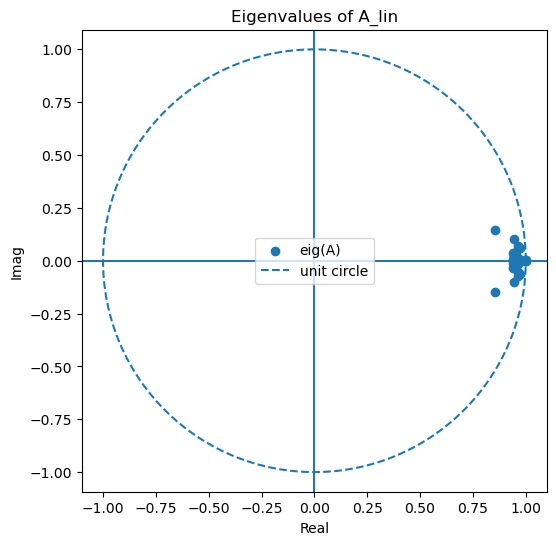

✅ U_curr 与 X_curr 样本数匹配: 99
✅ U_curr 与 X_curr 样本数匹配: 99
x_unchanged_scaled shape: (99, 6)
u_scaled shape: (99, 2)
x_changed_scaled shape: (99, 6)
x_changed_prime_scaled shape: (99, 0)


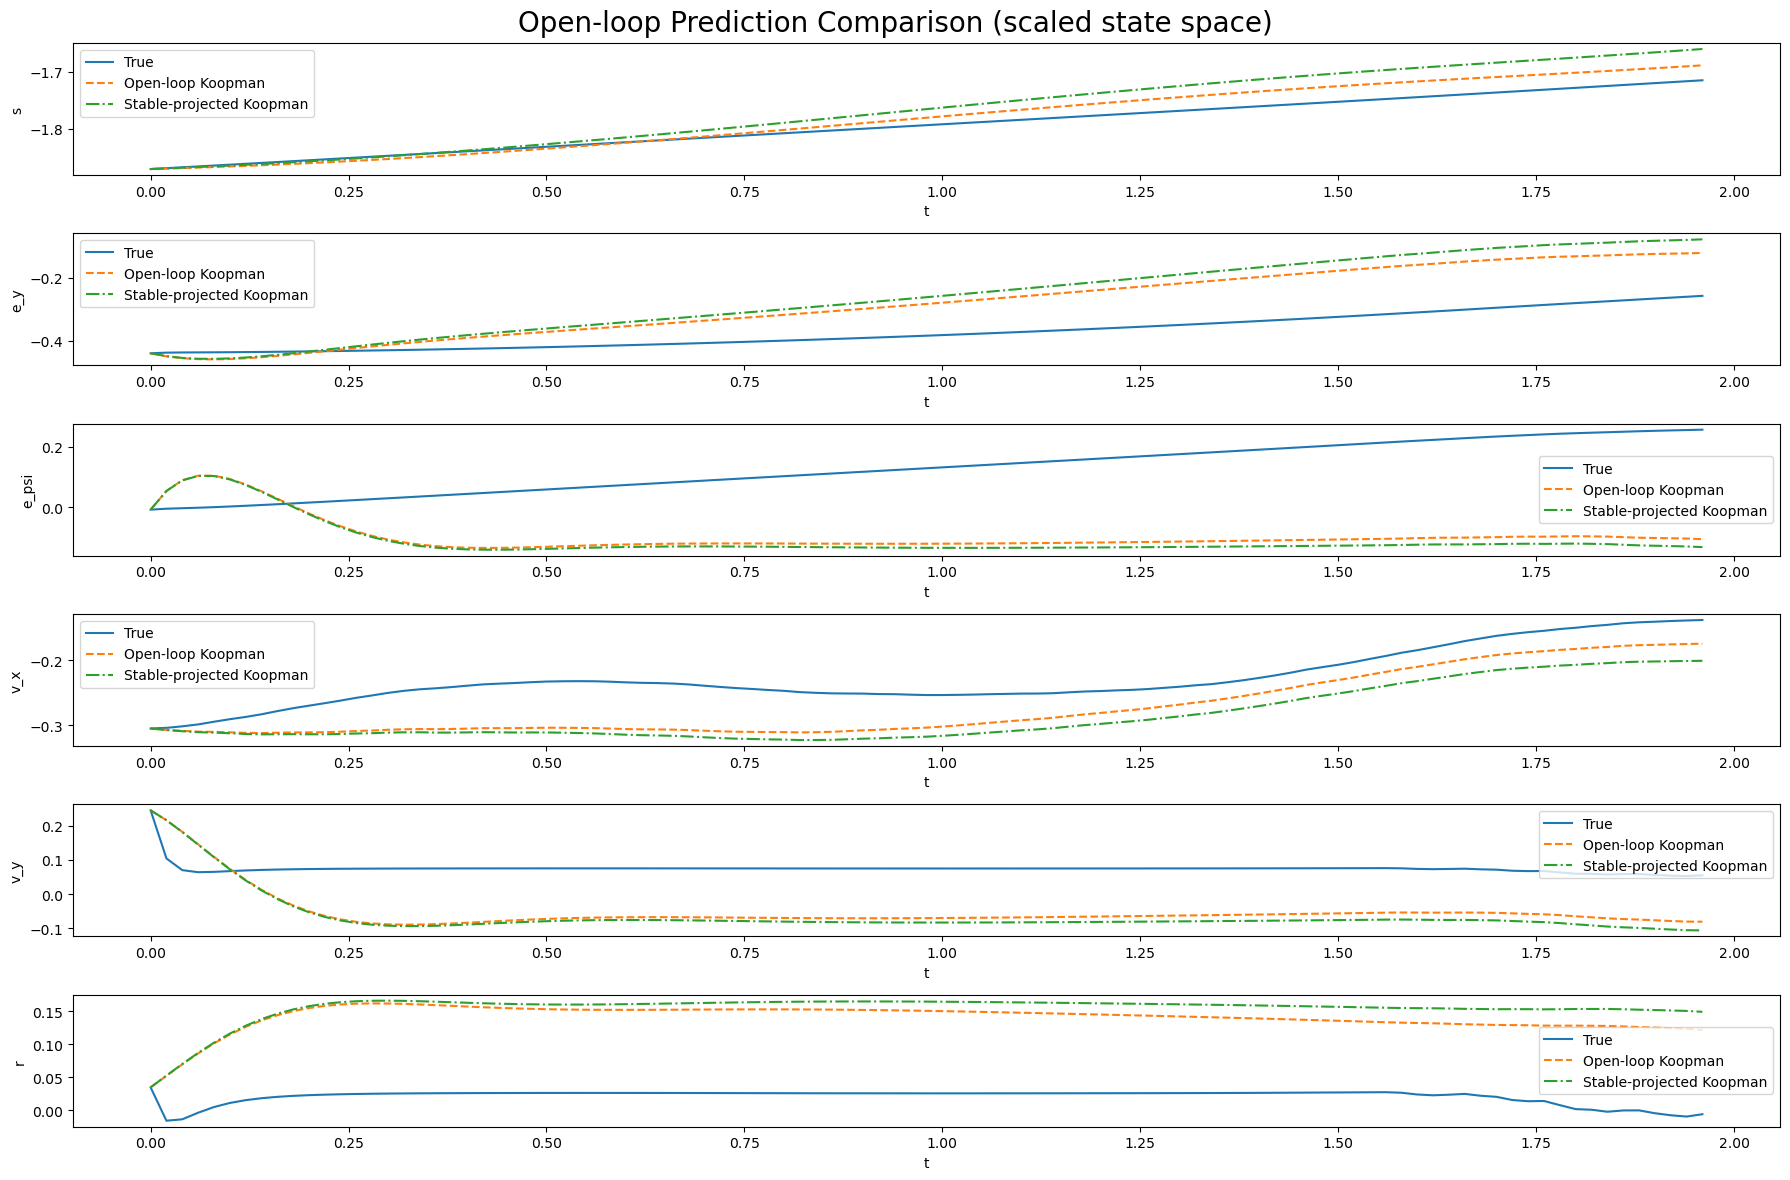

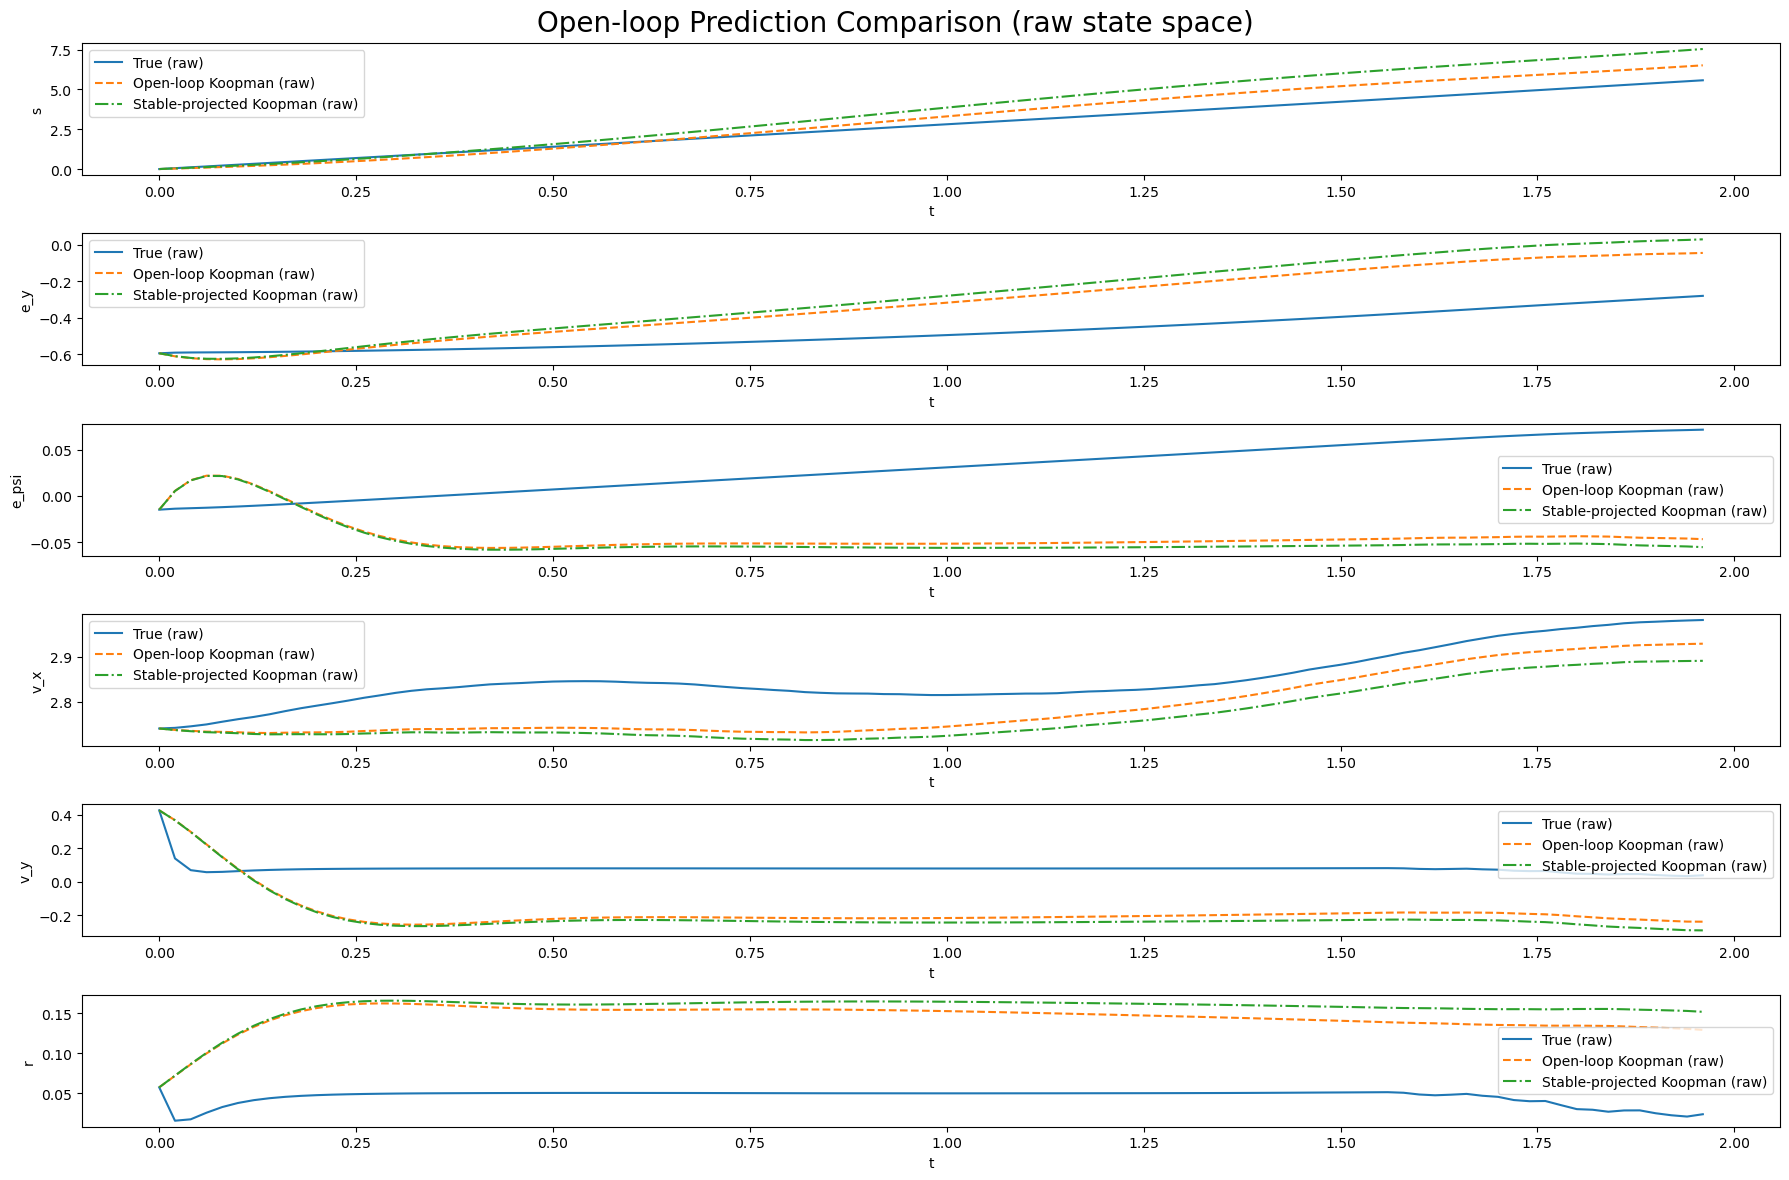

进行 one-step 预测 | 样本数: 99 | 状态维: 6


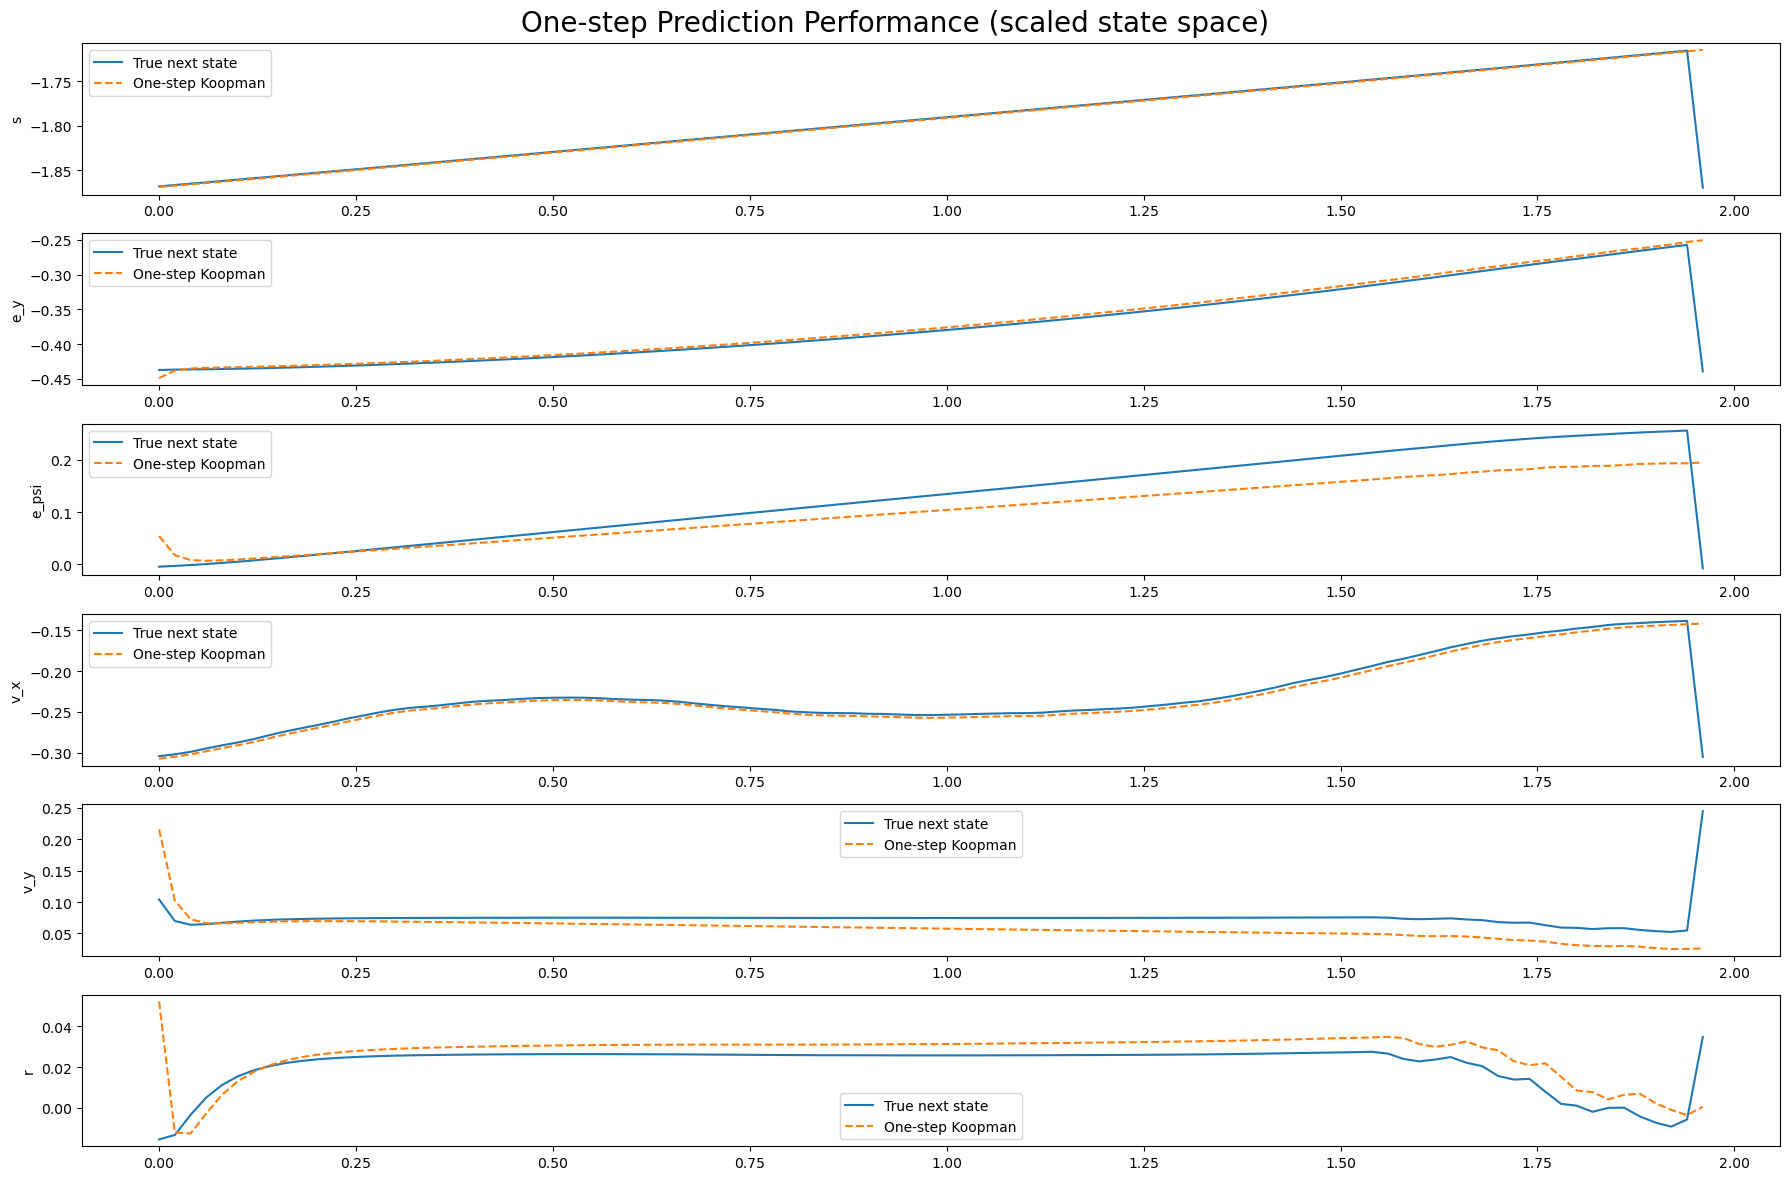

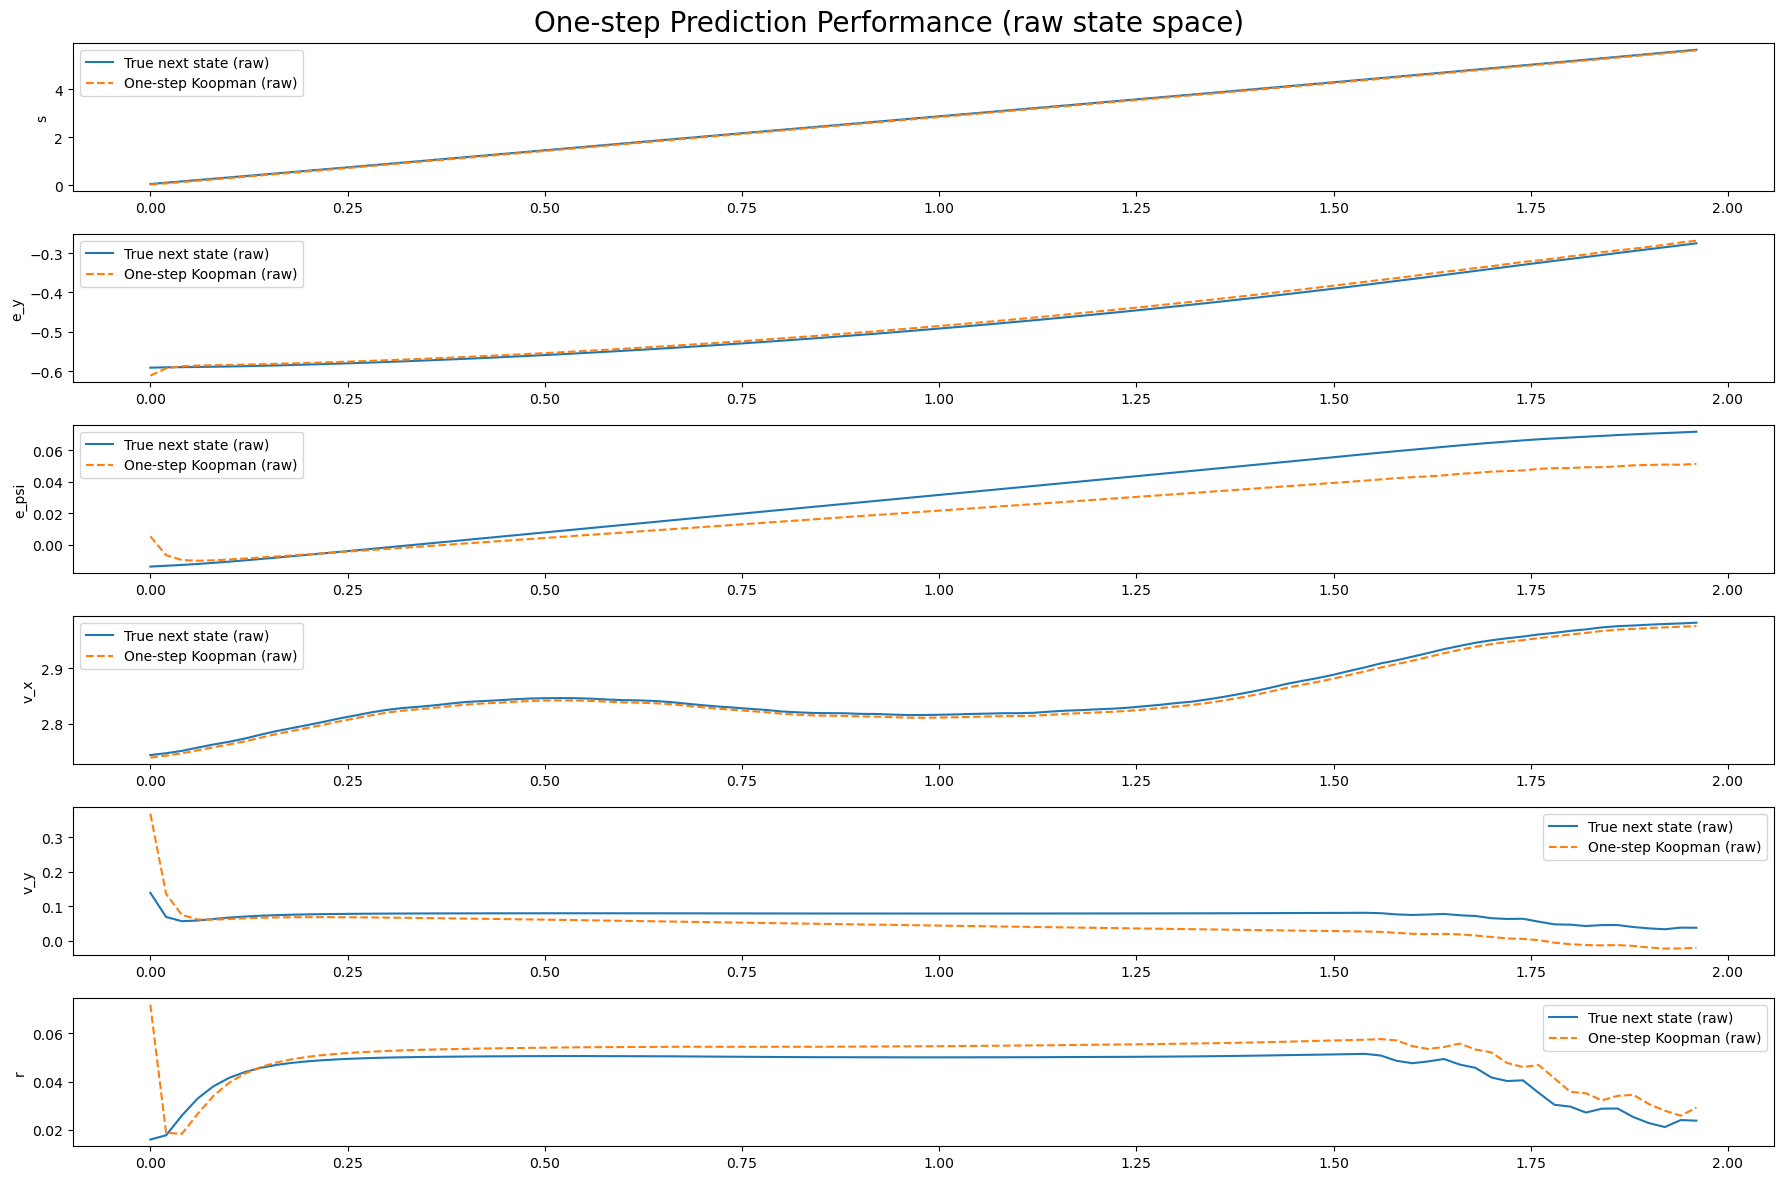

In [6]:

# =============================================================================
# Koopman Model Parameters (Open Loop Test)
# =============================================================================
num_snaps_test = 100
T_test = np.linspace(0, (num_snaps_test - 1) * dt, num_snaps_test)

num_traj_test = 1
first_obs_const = int(net_params_lin["first_obs_const"])
override_C = net_params_lin["override_C"]
if override_C:
    n_obs_lin = int(net_params_lin["encoder_output_dim"]) + num_states + first_obs_const
else:
    n_obs_lin = int(net_params_lin["encoder_output_dim"]) + first_obs_const

x_unchanged_test, x_changed_test, u_test = single_vehicle_data_gen_multi(
    num_traj_test, num_snaps_test, sys_pars, sys_pars_new, sensor_noise, SNR_DB
)

# A_lin = np.array(model_koop_dnn_lin.A)
# B_lin = np.array(model_koop_dnn_lin.B)
# C_lin = np.array(model_koop_dnn_lin.C)

# ====================== 正确提取 Koopman 矩阵 ======================
# ====================== 正确提取 Koopman 矩阵 ======================
if not hasattr(model_koop_dnn_lin, 'A_lin'):
    print("⚠️ 尚未调用 construct_koopman_model()，现在自动调用...")
    model_koop_dnn_lin.construct_koopman_model()

A_lin = model_koop_dnn_lin.A_lin
B_lin = model_koop_dnn_lin.B_lin
C_lin = model_koop_dnn_lin.C_np

print("A, B, C shapes:", A_lin.shape, B_lin.shape, C_lin.shape)

eigvals, eigvecs = np.linalg.eig(A_lin)
eigvals_proj = np.array([
    ev if np.abs(ev) <= 0.999 else ev / np.abs(ev) * 0.999
    for ev in eigvals
])
A_lin_stable = eigvecs @ np.diag(eigvals_proj) @ np.linalg.inv(eigvecs)
A_lin_stable = np.real(A_lin_stable)

eigvals_stable = np.linalg.eigvals(A_lin_stable)
print("stable spectral radius =", np.max(np.abs(eigvals_stable)))

print("A, B, C shapes:", A_lin.shape, B_lin.shape, C_lin.shape)

eigvals = np.linalg.eigvals(A_lin)
spectral_radius = np.max(np.abs(eigvals))

print("spectral radius =", spectral_radius)
print("eigvals =", eigvals)

plt.figure(figsize=(6, 6))
plt.scatter(np.real(eigvals), np.imag(eigvals), label="eig(A)")
theta = np.linspace(0, 2 * np.pi, 400)
plt.plot(np.cos(theta), np.sin(theta), "--", label="unit circle")
plt.axhline(0)
plt.axvline(0)
plt.xlabel("Real")
plt.ylabel("Imag")
plt.legend()
plt.title("Eigenvalues of A_lin")
plt.axis("equal")
plt.show()

X_unchanged_scaled, _ = model_koop_dnn_lin.net.process(x_unchanged_test, data_u=u_test)
X_changed_scaled, _ = model_koop_dnn_lin.net.process(x_changed_test, data_u=u_test)

x_unchanged_scaled = X_unchanged_scaled[:, :num_states]
u_scaled = X_unchanged_scaled[:, num_states:num_states + num_inputs]
x_unchanged_prime_scaled = X_unchanged_scaled[:, num_states + num_inputs:]

x_changed_scaled = X_changed_scaled[:, :num_states]
x_changed_prime_scaled = X_changed_scaled[:, num_states + num_inputs:]

print("x_unchanged_scaled shape:", x_unchanged_scaled.shape)
print("u_scaled shape:", u_scaled.shape)
print("x_changed_scaled shape:", x_changed_scaled.shape)
print("x_changed_prime_scaled shape:", x_changed_prime_scaled.shape)

num_pred = x_unchanged_scaled.shape[0]

z_lin = np.zeros((num_pred, n_obs_lin))
x_est_lin = np.zeros((num_pred, num_states))

z_lin[0, :] = lift_scaled(x_unchanged_scaled[0, :], model_koop_dnn_lin, net_params_lin)
# with torch.no_grad():
#     x_input = torch.from_numpy(x_unchanged_scaled[0:1, :].astype(np.float32)).to(model_koop_dnn_lin.net.device)
#     z0 = model_koop_dnn_lin.net.lift(x_input)
#     z_lin[0, :] = z0.squeeze(0).cpu().numpy()

x_est_lin[0, :] = np.matmul(z_lin[0, :], C_lin.T)

for k in range(num_pred - 1):
    z_lin[k + 1, :] = np.matmul(z_lin[k, :], A_lin.T) + np.matmul(u_scaled[k, :], B_lin.T)
    x_est_lin[k + 1, :] = np.matmul(z_lin[k + 1, :], C_lin.T)

z_lin_stable = np.zeros((num_pred, n_obs_lin))
x_est_lin_stable = np.zeros((num_pred, num_states))

z_lin_stable[0, :] = lift_scaled(x_unchanged_scaled[0, :], model_koop_dnn_lin, net_params_lin)
x_est_lin_stable[0, :] = np.matmul(z_lin_stable[0, :], C_lin.T)

for k in range(num_pred - 1):
    z_lin_stable[k + 1, :] = np.matmul(z_lin_stable[k, :], A_lin_stable.T) + np.matmul(u_scaled[k, :], B_lin.T)
    x_est_lin_stable[k + 1, :] = np.matmul(z_lin_stable[k + 1, :], C_lin.T)

T_plot = np.arange(num_pred) * dt

plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.xlabel("t")
    plt.ylabel(state_labels[i])
    plt.plot(T_plot, x_unchanged_scaled[:, i], label="True")
    plt.plot(T_plot, x_est_lin[:, i], "--", label="Open-loop Koopman")
    plt.plot(T_plot, x_est_lin_stable[:, i], "-.", label="Stable-projected Koopman")
    plt.legend()

plt.suptitle("Open-loop Prediction Comparison (scaled state space)", fontsize=20)
plt.tight_layout()
plt.show()

x_est_lin_raw = standardizer_x_kdnn.inverse_transform(x_est_lin)
x_est_lin_stable_raw = standardizer_x_kdnn.inverse_transform(x_est_lin_stable)
x_true_raw = x_unchanged_test[0, :-1, :]

plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.xlabel("t")
    plt.ylabel(state_labels[i])
    plt.plot(T_plot, x_true_raw[:, i], label="True (raw)")
    plt.plot(T_plot, x_est_lin_raw[:, i], "--", label="Open-loop Koopman (raw)")
    plt.plot(T_plot, x_est_lin_stable_raw[:, i], "-.", label="Stable-projected Koopman (raw)")
    plt.legend()

plt.suptitle("Open-loop Prediction Comparison (raw state space)", fontsize=20)
plt.tight_layout()
plt.show()

# ====================== One-step Prediction (修复空数组问题) ======================
# 正确计算有效样本数（process 已经切掉了最后一步）
num_pred = x_unchanged_scaled.shape[0]          # 应该等于 99

# 正确初始化（使用 num_pred 而不是像 x_unchanged_prime_scaled 这样可能为空的变量）
x_one_step_pred = np.zeros((num_pred, num_states))

print(f"进行 one-step 预测 | 样本数: {num_pred} | 状态维: {num_states}")

for k in range(num_pred):
    z_k = lift_scaled(x_unchanged_scaled[k, :], model_koop_dnn_lin, net_params_lin)
    z_k1 = np.matmul(z_k, A_lin.T) + np.matmul(u_scaled[k, :], B_lin.T)
    x_one_step_pred[k, :] = np.matmul(z_k1, C_lin.T)

T_plot_1 = np.arange(num_pred) * dt

# ====================== 绘图（scaled） ======================
plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    # plt.plot(T_plot_1, x_unchanged_prime_scaled[:num_pred, i] if x_unchanged_prime_scaled.shape[1] > 0 else x_unchanged_scaled[:, i],
    # 更符合逻辑的替代写法
    true_next = x_unchanged_prime_scaled[:num_pred, i] if x_unchanged_prime_scaled.shape[1] > 0 else np.roll(x_unchanged_scaled[:, i], -1)
    plt.plot(T_plot_1, true_next, label="True next state")
         # label="True next state")
    # plt.plot(T_plot_1, x_unchanged_prime_scaled[:num_pred, i] if x_unchanged_prime_scaled.shape[0] > 0 else x_unchanged_scaled[:, i],
    #          label="True next state")
    plt.plot(T_plot_1, x_one_step_pred[:, i], "--", label="One-step Koopman")
    plt.ylabel(state_labels[i])
    plt.legend()
plt.suptitle("One-step Prediction Performance (scaled state space)", fontsize=20)
plt.tight_layout()
plt.show()

# ====================== 绘图（raw） ======================
x_one_step_pred_raw = standardizer_x_kdnn.inverse_transform(x_one_step_pred)

# True next state（注意对齐）
x_true_next_raw = x_unchanged_test[0, 1:1+num_pred, :]

T_plot_raw = np.arange(num_pred) * dt

plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.plot(T_plot_raw, x_true_next_raw[:, i], label="True next state (raw)")
    plt.plot(T_plot_raw, x_one_step_pred_raw[:, i], "--", label="One-step Koopman (raw)")
    plt.ylabel(state_labels[i])
    plt.legend()
plt.suptitle("One-step Prediction Performance (raw state space)", fontsize=20)
plt.tight_layout()
plt.show()

# x_one_step_pred = np.zeros_like(x_unchanged_prime_scaled)
#
# for k in range(num_pred):
#     z_k = lift_scaled(x_unchanged_scaled[k, :], model_koop_dnn_lin, net_params_lin)
#     z_k1 = np.matmul(z_k, A_lin.T) + np.matmul(u_scaled[k, :], B_lin.T)
#     x_one_step_pred[k, :] = np.matmul(z_k1, C_lin.T)
#
# T_plot_1 = np.arange(x_one_step_pred.shape[0]) * dt
#
# plt.figure(figsize=(18, 12))
# for i in range(num_states):
#     plt.subplot(num_states, 1, i + 1)
#     plt.plot(T_plot_1, x_unchanged_prime_scaled[:, i], label="True next state")
#     plt.plot(T_plot_1, x_one_step_pred[:, i], "--", label="One-step Koopman")
#     plt.ylabel(state_labels[i])
#     plt.legend()
# plt.suptitle("One-step Prediction Performance (scaled state space)", fontsize=20)
# plt.tight_layout()
# plt.show()
#
# x_one_step_pred_raw = standardizer_x_kdnn.inverse_transform(x_one_step_pred)
# x_true_next_raw = x_unchanged_test[0, 1:, :]
#
# T_plot_raw = np.arange(x_true_next_raw.shape[0]) * dt
#
# plt.figure(figsize=(18, 12))
# for i in range(num_states):
#     plt.subplot(num_states, 1, i + 1)
#     plt.plot(T_plot_raw, x_true_next_raw[:, i], label="True next state (raw)")
#     plt.plot(T_plot_raw, x_one_step_pred_raw[:, i], "--", label="One-step Koopman (raw)")
#     plt.ylabel(state_labels[i])
#     plt.legend()
# plt.suptitle("One-step Prediction Performance (raw state space)", fontsize=20)
# plt.tight_layout()
# plt.show()

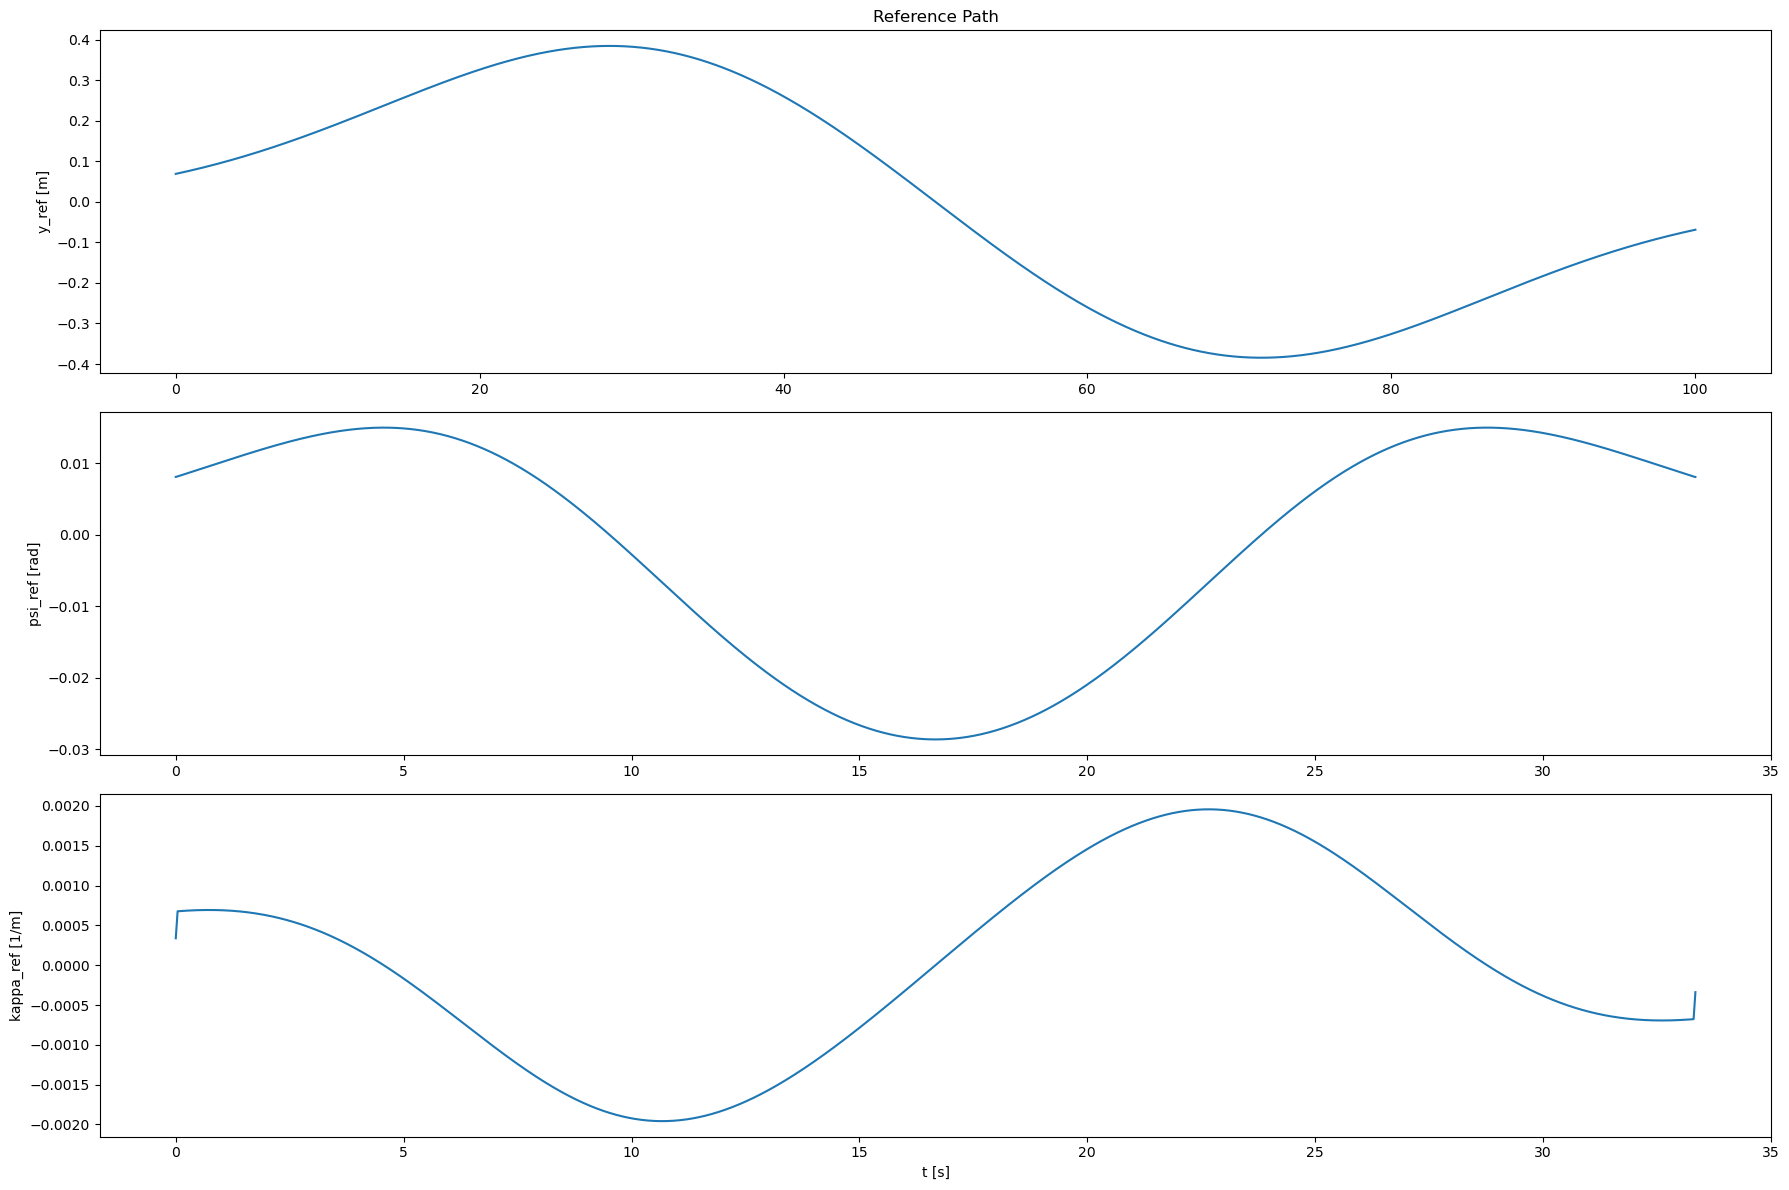

In [7]:

# =============================================================================
# Testing - 100m Double Lane Change Baseline
# =============================================================================

# =========================
# Reference path generation
# =========================
path_length = 100.0

vx_nom = 3.0
T_traj = path_length / vx_nom
t_ref = np.arange(0, T_traj + dt, dt)
traj_length = t_ref.size
x_path = vx_nom * t_ref

A1 = 0.4
A2 = -0.4
x1 = 30.0
x2 = 70.0
sigma1 = 16.0
sigma2 = 16.0

y_ref_path = (
        A1 * np.exp(-0.5 * ((x_path - x1) / sigma1) ** 2)
        + A2 * np.exp(-0.5 * ((x_path - x2) / sigma2) ** 2)
)

s_ref_path, psi_ref_path, curvature_ref_path = build_test_frenet_path_from_xy(
    x_path, y_ref_path
)

x_ref_raw = np.zeros((num_states, traj_length))
x_ref_raw[0, :] = s_ref_path
x_ref_raw[1, :] = 0.0
x_ref_raw[2, :] = 0.0
x_ref_raw[3, :] = vx_nom
x_ref_raw[4, :] = 0.0
x_ref_raw[5, :] = vx_nom * curvature_ref_path

x_ref_scaled = standardizer_x_kdnn.transform(x_ref_raw.T).T

plt.figure(figsize=(18, 12))
plt.subplot(3, 1, 1)
plt.plot(x_path, y_ref_path)
plt.ylabel("y_ref [m]")
plt.title("Reference Path")

plt.subplot(3, 1, 2)
plt.plot(t_ref, psi_ref_path)
plt.ylabel("psi_ref [rad]")

plt.subplot(3, 1, 3)
plt.plot(t_ref, curvature_ref_path)
plt.ylabel("kappa_ref [1/m]")
plt.xlabel("t [s]")
plt.tight_layout()
plt.show()

# =========================
# Solver settings
# =========================
solver_settings = {}
solver_settings["gen_embedded_ctrl"] = False
solver_settings["warm_start"] = True
solver_settings["polish"] = True
solver_settings["polish_refine_iter"] = 5
solver_settings["scaling"] = True
solver_settings["adaptive_rho"] = True
solver_settings["check_termination"] = 25
solver_settings["max_iter"] = 30000
solver_settings["eps_abs"] = 5e-4
solver_settings["eps_rel"] = 5e-4
solver_settings["eps_prim_inf"] = 1e-3
solver_settings["eps_dual_inf"] = 1e-3

In [9]:

# =========================
# MPC horizon / ref preview
# =========================
N_lin_noadapt = 80
max_iter_lin = 5

x_ref_mpc = np.hstack((
    x_ref_scaled,
    np.tile(x_ref_scaled[:, -1].reshape(-1, 1), N_lin_noadapt + 2)
))



# =========================
# Relaxed raw bounds -> scaled bounds
# =========================
xmin_raw = np.array([-10.0, -5.0, -1.2, 0.5, -4.0, -3.0])
xmax_raw = np.array([500.0, 5.0, 1.2, 8.0, 4.0, 3.0])

xmin_lin_noadapt = standardizer_x_kdnn.transform(xmin_raw.reshape(1, -1)).flatten()
xmax_lin_noadapt = standardizer_x_kdnn.transform(xmax_raw.reshape(1, -1)).flatten()

umax_lin_noadapt = np.array([0.08, 1.0])
umin_lin_noadapt = -umax_lin_noadapt

# =========================
# Closed-loop arrays in raw space
# =========================
xt_actual_lin_noadapt = np.zeros((traj_length, num_states))
xt_actual_lin_noadapt[0, :] = np.array([0.0, 0.0, 0.0, vx_nom, 0.0, 0.0])

u_lin_noadapt = np.zeros((traj_length - 1, num_inputs))

z_lin_noadapt = np.zeros((traj_length, n_obs_lin))
n_lift = A_lin.shape[0]

# =========================
# Initial guesses
# =========================
x_init_lin_noadapt_raw = np.tile(xt_actual_lin_noadapt[0, :], (N_lin_noadapt + 1, 1))
u_init_lin_noadapt = np.zeros((N_lin_noadapt, num_inputs))
z_init_lin_noadapt = np.zeros((N_lin_noadapt + 1, n_lift))

for ii in range(N_lin_noadapt + 1):
    xii_scaled = scale_state(x_init_lin_noadapt_raw[ii, :], standardizer_x_kdnn)
    z_init_lin_noadapt[ii, :] = lift_scaled(
        xii_scaled, model_koop_dnn_lin, net_params_lin
    )

# ====================== 使用示例：准备基础权重 ======================
# 把你原来的固定权重改成“基础权重”
Q_base_lin = scipy.sparse.diags([
    0.0,  # s
    3500.0,  # e_y base
    1200.0,  # e_psi base
    8.0,  # v_x
    1.0,  # v_y
    1.0  # r
])

QN_base_lin = scipy.sparse.diags([
    0.0,
    5000.0,
    2000.0,
    12.0,
    1.0,
    1.0
])

R_mpc_lin_noadapt = scipy.sparse.diags([120.0, 12.0])  # R通常不自适应

# =========================
# Controller
# =========================
linear_model_no_adapt = linear_Dynamics(
    scipy.sparse.csc_matrix(A_lin_stable),
    scipy.sparse.csc_matrix(B_lin),
    C_lin
)

# 使用基础权重初始化控制器（后面会动态覆盖）
controller_nmpc_lin_noadapt = NonlinearMPCController(
    linear_model_no_adapt,
    N_lin_noadapt, dt, umin_lin_noadapt, umax_lin_noadapt,
    xmin_lin_noadapt, xmax_lin_noadapt,
    Q_base_lin, R_mpc_lin_noadapt, QN_base_lin,  # 保持原样
    solver_settings
)



controller_nmpc_lin_noadapt.construct_controller(
    z_init_lin_noadapt, u_init_lin_noadapt, x_ref_scaled[:, 0]
)


# =========================
# 3. 定义自适应函数
# =========================

def adaptive_mpc_weights(error_ey, error_epsi, base_Q, base_QN, base_R,
                         ey_scale=0.8, epsi_scale=0.9,
                         max_mult=2.8, min_mult=0.85):
    ey_norm = min(abs(error_ey) / 1.8, 1.0)
    epsi_norm = min(abs(error_epsi) / 0.7, 1.0)

    mult_ey = 1.0 + (max_mult - 1.0) * (ey_norm ** 1.1)
    mult_epsi = 1.0 + (max_mult - 1.0) * (epsi_norm ** 1.1)

    mult_ey = np.clip(mult_ey * ey_scale, min_mult, max_mult)
    mult_epsi = np.clip(mult_epsi * epsi_scale, min_mult, max_mult)

    Q_diag = base_Q.diagonal().copy()
    QN_diag = base_QN.diagonal().copy()

    Q_diag[1] *= mult_ey
    Q_diag[2] *= mult_epsi
    QN_diag[1] *= mult_ey * 1.25
    QN_diag[2] *= mult_epsi * 1.25

    Q_adapt = scipy.sparse.diags(Q_diag, offsets=0, format='dia')
    QN_adapt = scipy.sparse.diags(QN_diag, offsets=0, format='dia')

    # R 轻微自适应（误差大时降低 R，让控制更主动）
    R_diag = base_R.diagonal().copy()
    mult_r = 1.0 - 0.25 * (max(mult_ey, mult_epsi) - 1.0)
    R_diag = R_diag * np.clip(mult_r, 0.75, 1.0)
    R_adapt = scipy.sparse.diags(R_diag, offsets=0, format='dia')

    return Q_adapt, QN_adapt, R_adapt



In [10]:


# =========================
# Closed-loop simulation
# =========================
delta_alpha = 0.6
ax_alpha = 0.50

sys_pars_ctrl = dict(sys_pars_new)
sys_pars_ctrl["vx_ref"] = vx_nom
sys_pars_ctrl["uncertainty"] = "NA"
sys_pars_ctrl["amp"] = 0.0
sys_pars_ctrl["freq"] = 1.0
sys_pars_ctrl["s_ref"] = s_ref_path
sys_pars_ctrl["curvature_ref"] = curvature_ref_path

begin_linear_noadapt = time.time()
time_excess = 0.0
fail_count = 0
nonfinite_count = 0
terminated_early = False

for k in range(traj_length - 1):
    xk_raw = xt_actual_lin_noadapt[k, :].copy()

    if not is_finite_vector(xk_raw):
        print(f"[STOP] Non-finite state before scaling at step {k}")
        print("xk_raw =", xk_raw)
        terminated_early = True
        break

    xk_raw = clip_closed_loop_state(xk_raw, s_upper=500.0)
    xt_actual_lin_noadapt[k, :] = xk_raw

    # ==================== 自适应权重计算（本次重点调整） ====================
    current_ey = xt_actual_lin_noadapt[k, 1]
    current_epsi = xt_actual_lin_noadapt[k, 2]

    # 误差阈值放宽一点，让自适应更早介入
    if abs(current_ey) > 0.04 or abs(current_epsi) > 0.025:
        Q_mpc_adapt, QN_mpc_adapt, R_mpc_adapt = adaptive_mpc_weights(
            error_ey=current_ey,
            error_epsi=current_epsi,
            base_Q=Q_base_lin,
            base_QN=QN_base_lin,
            base_R=R_mpc_lin_noadapt,
            ey_scale=0.8,
            epsi_scale=0.9,
            max_mult=2.8,  # 这次调到5.0，动态范围更大
            min_mult=0.85
        )
    else:
        Q_mpc_adapt = Q_base_lin
        QN_mpc_adapt = QN_base_lin
        R_mpc_adapt = R_mpc_lin_noadapt

    # 更新权重
    controller_nmpc_lin_noadapt.Q = Q_mpc_adapt
    controller_nmpc_lin_noadapt.QN = QN_mpc_adapt
    controller_nmpc_lin_noadapt.R = R_mpc_adapt
    # -------------------------------------------------
    # scale state
    # -------------------------------------------------
    try:
        xk_scaled = scale_state(xk_raw, standardizer_x_kdnn)
    except Exception as e:
        print(f"[STOP] scale_state failed at step {k}: {e}")
        print("xk_raw =", xk_raw)
        terminated_early = True
        break

    if not is_finite_vector(xk_scaled):
        print(f"[STOP] Non-finite scaled state at step {k}")
        print("xk_raw =", xk_raw)
        print("xk_scaled =", xk_scaled)
        terminated_early = True
        break

    # -------------------------------------------------
    # 1) 提升到 Koopman 空间
    # -------------------------------------------------
    try:
        z_lin_noadapt[k, :] = lift_scaled(
            xk_scaled, model_koop_dnn_lin, net_params_lin
        )
    except Exception as e:
        print(f"[STOP] lift_scaled failed at step {k}: {e}")
        print("xk_scaled =", xk_scaled)
        terminated_early = True
        break

    if not is_finite_vector(z_lin_noadapt[k, :]):
        print(f"[STOP] Non-finite lifted state at step {k}")
        print("z =", z_lin_noadapt[k, :])
        terminated_early = True
        break

    # -------------------------------------------------
    # 2) 取参考窗口
    # -------------------------------------------------
    xref_win = x_ref_mpc[:, k + 1:k + N_lin_noadapt + 2]

    # -------------------------------------------------
    # 3) 求解 MPC
    # -------------------------------------------------
    mpc_ok = True
    try:
        controller_nmpc_lin_noadapt.solve_to_convergence(
            xref_win,
            z_lin_noadapt[k, :],
            controller_nmpc_lin_noadapt.z_init,
            controller_nmpc_lin_noadapt.u_init,
            max_iter=max_iter_lin,
            eps=1e-3
        )
        controller_nmpc_lin_noadapt.update_initial_guess_()

        delta_fb_mpc = float(controller_nmpc_lin_noadapt.cur_u[0, 0])
        ax_cmd = float(controller_nmpc_lin_noadapt.cur_u[0, 1])

        if not np.isfinite(delta_fb_mpc) or not np.isfinite(ax_cmd):
            raise ValueError("MPC returned non-finite control")
    except Exception as e:
        fail_count += 1
        print(f"[WARN] MPC fallback at step {k}: {e}")

        if k > 0:
            delta_fb_mpc = float(u_lin_noadapt[k - 1, 0])
            ax_cmd = float(u_lin_noadapt[k - 1, 1])
        else:
            delta_fb_mpc = 0.0
            ax_cmd = 0.0

    # -------------------------------------------------
    # 4) 前馈 + 裁剪
    # -------------------------------------------------
    ff_gain = 0.8
    delta_ff = ff_gain * (sys_pars["lf"] + sys_pars["lr"]) * curvature_ref_path[k]
    delta_cmd_raw = delta_fb_mpc + delta_ff

    delta_cmd_raw = np.clip(delta_cmd_raw, umin_lin_noadapt[0], umax_lin_noadapt[0])
    ax_cmd = np.clip(ax_cmd, umin_lin_noadapt[1], umax_lin_noadapt[1])

    # -------------------------------------------------
    # 5) 输入平滑
    # -------------------------------------------------
    if k == 0:
        delta_applied = delta_cmd_raw
        ax_applied = ax_cmd
    else:
        delta_applied = delta_alpha * u_lin_noadapt[k - 1, 0] + (1.0 - delta_alpha) * delta_cmd_raw
        ax_applied = ax_alpha * u_lin_noadapt[k - 1, 1] + (1.0 - ax_alpha) * ax_cmd

    delta_applied = np.clip(delta_applied, umin_lin_noadapt[0], umax_lin_noadapt[0])
    ax_applied = np.clip(ax_applied, umin_lin_noadapt[1], umax_lin_noadapt[1])

    if k >= traj_length - 5 and k > 0:
        u_lin_noadapt[k, :] = u_lin_noadapt[k - 1, :]
    else:
        u_lin_noadapt[k, 0] = delta_applied
        u_lin_noadapt[k, 1] = ax_applied

    # -------------------------------------------------
    # 6) 推进一步真实系统
    # -------------------------------------------------
    t1 = time.time()

    if k > 0:
        fallback_state = xt_actual_lin_noadapt[k, :].copy()
    else:
        fallback_state = np.array([0.0, 0.0, 0.0, vx_nom, 0.0, 0.0], dtype=float)

    x_next = safe_FK_step(
        xt_actual_lin_noadapt[k, :],
        u_lin_noadapt[k, :],
        sys_pars_ctrl,
        SNR_DB=SNR_DB,
        i=k,
        fallback_state=fallback_state,
        verbose=True
    )

    t2 = time.time()
    time_excess += (t2 - t1)

    if not is_finite_vector(x_next):
        nonfinite_count += 1
        print(f"[STOP] x_next still non-finite at step {k}")
        print("x_now =", xt_actual_lin_noadapt[k, :])
        print("u_now =", u_lin_noadapt[k, :])
        terminated_early = True
        break

    xt_actual_lin_noadapt[k + 1, :] = x_next

end_linear_noadapt = time.time()

effective_steps = max(1, np.sum(np.any(np.abs(u_lin_noadapt) > 0, axis=1)))
time_linear_noadapt = (end_linear_noadapt - begin_linear_noadapt - time_excess) / max(1, traj_length - 1)

print("Average MPC solve time per step =", time_linear_noadapt)
print("Total MPC failures =", fail_count)
print("Total non-finite next-state events =", nonfinite_count)
print("Terminated early =", terminated_early)

Average MPC solve time per step = 0.09532455805896926
Total MPC failures = 0
Total non-finite next-state events = 0
Terminated early = False


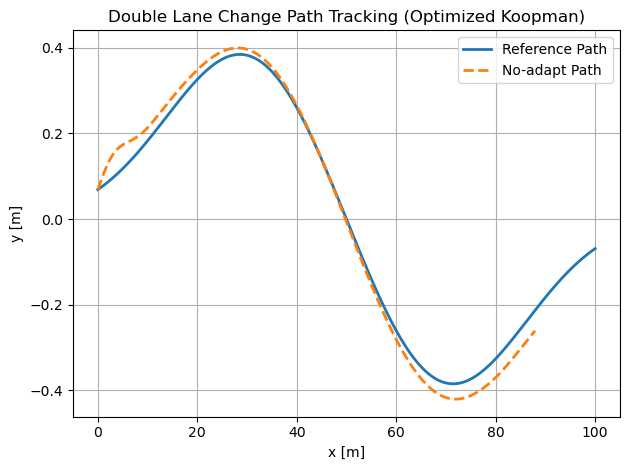

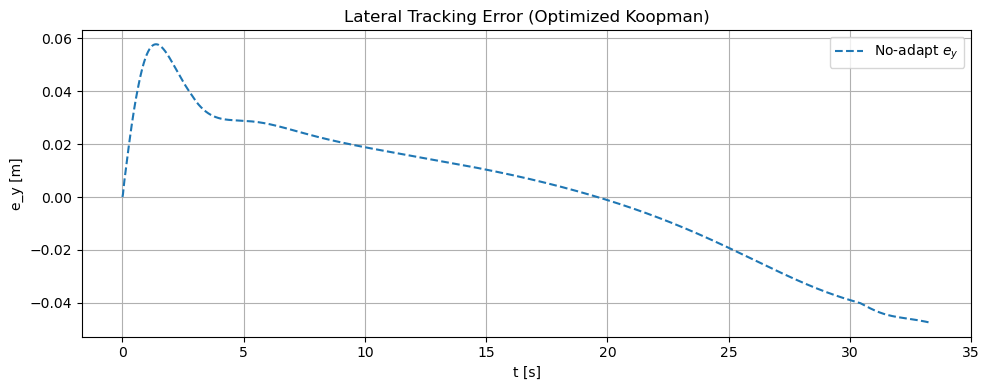

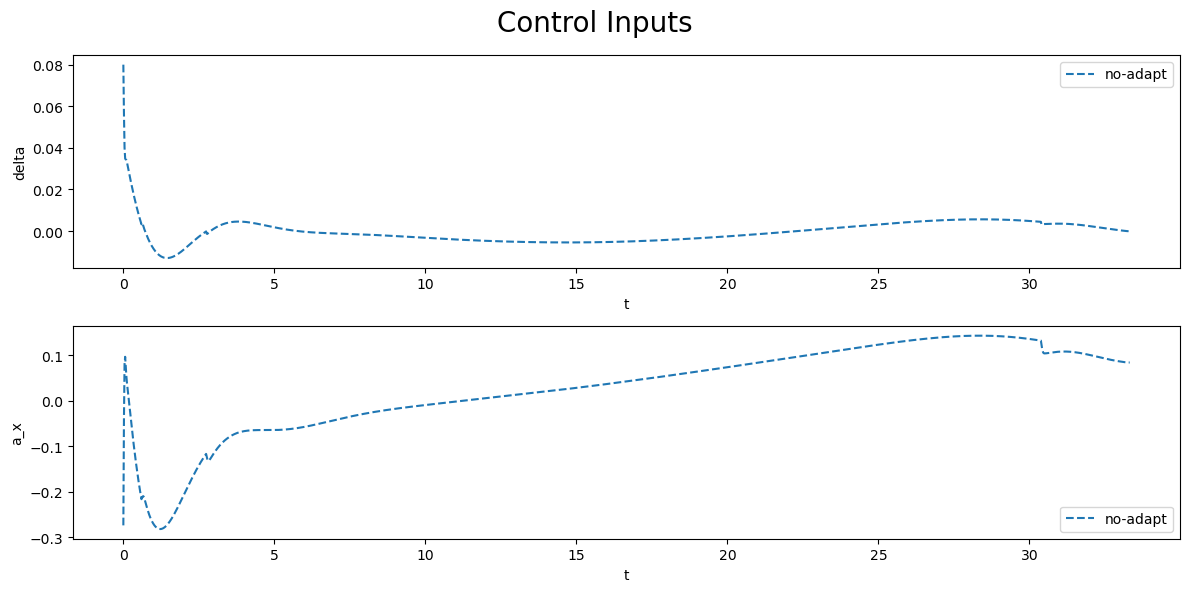

In [11]:

# =========================
# Plotting
# =========================


valid_len = traj_length
for idx in range(traj_length):
    if not is_finite_vector(xt_actual_lin_noadapt[idx, :]):
        valid_len = idx
        break

s_actual_noadapt = xt_actual_lin_noadapt[:valid_len, 0]
ey_actual_noadapt = xt_actual_lin_noadapt[:valid_len, 1]

x_actual_path_noadapt, y_actual_path_noadapt = frenet_to_global(
    s_actual_noadapt, ey_actual_noadapt, s_ref_path, x_path, y_ref_path, psi_ref_path
)
plt.plot(x_path, y_ref_path, label="Reference Path", linewidth=2)
plt.plot(x_actual_path_noadapt, y_actual_path_noadapt, "--", label="No-adapt Path", linewidth=2)
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Double Lane Change Path Tracking (Optimized Koopman)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(t_ref[:valid_len], xt_actual_lin_noadapt[:valid_len, 1], "--", label="No-adapt $e_y$")
plt.xlabel("t [s]")
plt.ylabel("e_y [m]")
plt.title("Lateral Tracking Error (Optimized Koopman)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
plt.figure(figsize=(12, 6))
for i in range(num_inputs):
    plt.subplot(num_inputs, 1, i + 1)
    plt.plot(t_ref[:-1], u_lin_noadapt[:, i], '--', label='no-adapt')
    # plt.plot(t_ref[:-1], u_lin_adapt[:, i], '-.', label='adapt')
    plt.ylabel(input_labels[i])
    plt.xlabel("t")
    plt.legend()

plt.suptitle("Control Inputs", fontsize=20)
plt.tight_layout()
plt.show()